In [20]:

import gc
import json
import math
import os
import platform
import random
import re
from contextlib import nullcontext
from pathlib import Path
from dataclasses import dataclass

import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne import Epochs

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset


In [2]:
# Reproducibility 

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    if hasattr(torch, "xpu") and torch.xpu.is_available():
        torch.xpu.manual_seed(seed)
        torch.xpu.manual_seed_all(seed)


def get_device():
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        return torch.device("xpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def get_device_name(device):
    if device.type == "xpu" and hasattr(torch, "xpu"):
        try:
            return torch.xpu.get_device_name(device)
        except Exception:
            return "Intel XPU"
    if device.type == "cuda":
        try:
            return torch.cuda.get_device_name(device)
        except Exception:
            return "CUDA GPU"
    return platform.processor() or "CPU"


def clear_device_cache():
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "xpu" and hasattr(torch, "xpu"):
        try:
            torch.xpu.empty_cache()
        except Exception:
            pass

seed_everything()

DEVICE = get_device()
DEVICE_TYPE = DEVICE.type
USE_XPU = DEVICE_TYPE == "xpu"
USE_CUDA = DEVICE_TYPE == "cuda"
USE_CPU = DEVICE_TYPE == "cpu"

print("torch version:", torch.__version__)
print("DEVICE:", DEVICE)
print("DEVICE NAME:", get_device_name(DEVICE))


torch version: 2.7.1+xpu
DEVICE: xpu
DEVICE NAME: Intel(R) Arc(TM) B580 Graphics


In [3]:
# Configuration

CONFIG = {
   
    "data_root": "/home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot",

    
    "event_json_path": "/home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/event_names.json",
    "montage_path": "/home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/montage.bvef",  # optional, only used if helpful

    
    "tmin": 0.0,
    "tmax": 2.0,
    "baseline": (0.0, 0.2),
    "l_freq": 1.0,
    "h_freq": 40.0,
    "resample_sfreq": 128,

    # Channel handling
    "drop_eog": True,
    "car_reference": True,
    "pick_eeg_only": True,

    # Training
    "batch_size": 8,
    "num_workers": 0,
    "lr_overt": 1e-3,
    "lr_imagined": 3e-4,
    "weight_decay": 1e-4,
    "epochs_overt": 10,
    "epochs_imagined": 25,
    "dropout": 0.5,

    # Transfer strategy
    "freeze_feature_extractor_during_transfer": False,

    # Evaluation split
    "test_size": 0.2,
    "val_size_from_train": 0.2,

    # Runtime / memory behaviour
    "prefetch_in_ram": False,
    "pin_memory": False,
    "non_blocking_transfer": False,

    # Subject/event capping to avoid RAM spikes
    "max_epochs_per_subject": 500,

    # End-to-end neuro-symbolic learning
    "symbolic_min_confidence": 0.35,
    "constraint_loss_weight": 0.20,
    "invalid_rule_init": 1.25,
    "repeat_rule_init": 0.35,
    "feasible_boost_init": 0.20,
    "gate_sharpness_init": 8.0,
    "explanation_examples_to_show": 10,

    # Event sidecar discovery
    "sidecar_extensions": [".csv", ".tsv", ".txt", ".json"],
}
CONFIG


{'data_root': '/home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot',
 'event_json_path': '/home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/event_names.json',
 'montage_path': '/home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/montage.bvef',
 'tmin': 0.0,
 'tmax': 2.0,
 'baseline': (0.0, 0.2),
 'l_freq': 1.0,
 'h_freq': 40.0,
 'resample_sfreq': 128,
 'drop_eog': True,
 'car_reference': True,
 'pick_eeg_only': True,
 'batch_size': 8,
 'num_workers': 0,
 'lr_overt': 0.001,
 'lr_imagined': 0.0003,
 'weight_decay': 0.0001,
 'epochs_overt': 10,
 'epochs_imagined': 25,
 'dropout': 0.5,
 'freeze_feature_extractor_during_transfer': False,
 'test_size': 0.2,
 'val_size_from_train': 0.2,
 'prefetch_in_ram': False,
 'pin_memory': False,
 'non_blocking_transfer': False,
 'max_epochs_per_subject': 500,
 'symbolic_min_confidence':

In [4]:

# Event dictionary

with open(CONFIG["event_json_path"], "r", encoding="utf-8") as f:
    event_info = json.load(f)

EVENT_DICT = event_info["Event_Dictionary"]
EVENT_DICT

{'Empty': 1,
 'EndOfEvent': 2,
 'EndOfLevel': 3,
 'EndOfParadigm': 4,
 'space_bar': 5,
 'Overt_Up': 11,
 'Overt_Left': 12,
 'Overt_Right': 13,
 'Overt_Pick': 14,
 'Overt_Push': 15,
 'Silent_Up': 21,
 'Silent_Left': 22,
 'Silent_Right': 23,
 'Silent_Pick': 24,
 'Silent_Push': 25}

In [5]:

# Command/paradigm mappings

EVENT_TO_COMMAND = {
    "Overt_Left": "left",
    "Overt_Right": "right",
    "Overt_Up": "up",
    "Overt_Pick": "pick",
    "Overt_Push": "push",
    "Silent_Left": "left",
    "Silent_Right": "right",
    "Silent_Up": "up",
    "Silent_Pick": "pick",
    "Silent_Push": "push",
}

EVENT_TO_PARADIGM = {
    "Overt_Left": "overt",
    "Overt_Right": "overt",
    "Overt_Up": "overt",
    "Overt_Pick": "overt",
    "Overt_Push": "overt",
    "Silent_Left": "imagined",
    "Silent_Right": "imagined",
    "Silent_Up": "imagined",
    "Silent_Pick": "imagined",
    "Silent_Push": "imagined",
}

TARGET_EVENT_IDS = {name: EVENT_DICT[name] for name in EVENT_TO_COMMAND.keys()}
TARGET_EVENT_IDS

{'Overt_Left': 12,
 'Overt_Right': 13,
 'Overt_Up': 11,
 'Overt_Pick': 14,
 'Overt_Push': 15,
 'Silent_Left': 22,
 'Silent_Right': 23,
 'Silent_Up': 21,
 'Silent_Pick': 24,
 'Silent_Push': 25}

In [6]:
# Discover FIF files

data_root = Path(CONFIG["data_root"])

def is_valid_fif_file(path: Path) -> bool:
    name = path.name
    # Ignore hidden metadata files such as macOS AppleDouble sidecars: ._file.fif
    if name.startswith('.') or name.startswith('._'):
        return False
    if path.suffix.lower() != '.fif':
        return False
    return path.is_file()

all_fif_candidates = sorted(data_root.rglob("*.fif"))
fif_files = [p for p in all_fif_candidates if is_valid_fif_file(p)]
ignored_fif_files = [p for p in all_fif_candidates if not is_valid_fif_file(p)]

print("Found", len(fif_files), "valid FIF files")
if ignored_fif_files:
    print("Ignored", len(ignored_fif_files), "hidden/invalid FIF-like files")
for p in fif_files[:10]:
    print(" -", p)
if ignored_fif_files[:5]:
    print("\nExamples of ignored files:")
    for p in ignored_fif_files[:5]:
        print(" -", p)
if not fif_files:
    print("Update CONFIG['data_root'] before continuing.")


Found 15 valid FIF files
Ignored 15 hidden/invalid FIF-like files
 - /home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/participant_1.fif
 - /home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/participant_10.fif
 - /home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/participant_11.fif
 - /home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/participant_12.fif
 - /home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/participant_13.fif
 - /home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/participant_14.fif
 - /home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/participant_15.fif
 - /home/naveed/Desktop/E

In [7]:
# Helpers 

try:
    from scipy.io import loadmat
except Exception:
    loadmat = None

def infer_subject_id(path: Path) -> str:
    stem = path.stem.lower().lstrip(".").lstrip("_")
    for pattern in [r"(participant[_-]?\d+)", r"(subject[_-]?\d+)", r"(sub[_-]?\d+)"]:
        m = re.search(pattern, stem)
        if m:
            return m.group(1)
    return stem

def infer_subject_number(subject_id: str):
    m = re.search(r"(\d+)$", str(subject_id))
    return int(m.group(1)) if m else None

def load_raw(path: Path):
    if not is_valid_fif_file(path):
        raise ValueError(f"Skipping hidden or invalid FIF file: {path}")
    raw = mne.io.read_raw_fif(path, preload=False, verbose="ERROR")

    if CONFIG["pick_eeg_only"]:
        keep_types = {"eeg", "stim", "eog", "misc"}
        keep_names = [
            ch for ch, kind in zip(raw.ch_names, raw.get_channel_types())
            if kind in keep_types
        ]
        if keep_names:
            raw.pick(keep_names)

    if CONFIG["drop_eog"]:
        eog_like = [ch for ch in raw.ch_names if "eog" in ch.lower()]
        if eog_like:
            raw.drop_channels(eog_like)

    return raw

def normalize_name(s):
    return re.sub(r"[^a-z0-9]+", "_", str(s).strip().lower()).strip("_")

def candidate_event_channels(raw):
    candidates = []
    ch_types = raw.get_channel_types()
    for ch_name, ch_type in zip(raw.ch_names, ch_types):
        name = ch_name.lower()
        if ch_type == "stim":
            candidates.append(ch_name)
            continue
        if any(token in name for token in ["stim", "sti", "status", "trigger", "trig", "marker", "event", "response", "resp"]):
            candidates.append(ch_name)
    seen = set()
    ordered = []
    for ch in candidates:
        if ch not in seen:
            ordered.append(ch)
            seen.add(ch)
    return ordered

def discover_sidecar_files(raw_path: Path, subject_id: str):
    allowed = {ext.lower() for ext in CONFIG.get(
        "sidecar_extensions",
        [".csv", ".tsv", ".txt", ".json", ".mat", ".npz", ".npy", ".xlsx", ".xls"]
    )}
    stem = raw_path.stem.lower()
    sid = subject_id.lower()
    sid_num = infer_subject_number(subject_id)
    candidates = []

    search_roots = [raw_path.parent]
    if raw_path.parent != data_root:
        search_roots.append(data_root)

    metadata_exts = {".csv", ".tsv", ".txt", ".json", ".mat", ".npz", ".npy", ".xlsx", ".xls"}
    keywords = ["event", "marker", "trigger", "label", "annotation", "trial", "segment", "epoch"]

    for root in search_roots:
        for path in root.rglob("*"):
            if not path.is_file():
                continue
            if path == raw_path:
                continue
            if path.name.startswith(".") or path.name.startswith("._"):
                continue
            low = path.name.lower()
            suffix = path.suffix.lower()

            keep = False
            if suffix in allowed or suffix in metadata_exts:
                keep = True
            if any(k in low for k in keywords):
                keep = True
            if stem in low or sid in low:
                keep = True
            if sid_num is not None and re.search(rf"(participant|subject|sub)[_-]?{sid_num}\b", low):
                keep = True

            if keep:
                candidates.append(path)

    uniq = []
    seen = set()
    for p in candidates:
        sp = str(p)
        if sp not in seen:
            uniq.append(p)
            seen.add(sp)
    return uniq

def _build_event_id_from_codes(codes):
    unique_codes = sorted(set(int(x) for x in codes))
    reverse = {int(v): k for k, v in EVENT_DICT.items()}
    event_id = {}
    for code in unique_codes:
        event_id[reverse.get(code, f"event_{code}")] = int(code)
    return event_id

def _read_table_sidecar(path: Path):
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".tsv":
        return pd.read_csv(path, sep="\t")
    if suffix in {".txt", ".log"}:
        try:
            return pd.read_csv(path, sep=None, engine="python")
        except Exception:
            return pd.read_csv(path, delim_whitespace=True)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    return None

def _events_from_dataframe(df, raw):
    if df is None or df.empty:
        return None

    cols = {normalize_name(c): c for c in df.columns}

    sample_col = next((cols[k] for k in ["sample", "sample_idx", "sample_index", "latency", "onset_sample"] if k in cols), None)
    code_col = next((cols[k] for k in ["event_id", "code", "value", "trigger", "marker", "event"] if k in cols), None)
    time_col = next((cols[k] for k in ["time", "onset", "start_time", "timestamp", "latency_sec"] if k in cols), None)
    label_col = next((cols[k] for k in ["label", "event_name", "name", "condition"] if k in cols), None)

    if sample_col is None and time_col is None:
        return None

    if sample_col is not None:
        samples = pd.to_numeric(df[sample_col], errors="coerce").dropna().astype(int).to_numpy()
        work_df = df.loc[pd.to_numeric(df[sample_col], errors="coerce").notna()].copy()
    else:
        times = pd.to_numeric(df[time_col], errors="coerce")
        work_df = df.loc[times.notna()].copy()
        samples = np.round(times.dropna().to_numpy() * raw.info["sfreq"]).astype(int)

    if len(samples) == 0:
        return None

    if code_col is not None:
        codes = pd.to_numeric(work_df[code_col], errors="coerce").fillna(-1).astype(int).to_numpy()
    elif label_col is not None:
        reverse_lookup = {normalize_name(k): int(v) for k, v in EVENT_DICT.items()}
        codes = []
        for val in work_df[label_col].astype(str):
            key = normalize_name(val)
            codes.append(reverse_lookup.get(key, -1))
        codes = np.asarray(codes, dtype=int)
    else:
        return None

    valid = codes > 0
    if not np.any(valid):
        return None

    events = np.column_stack([samples[valid], np.zeros(valid.sum(), dtype=int), codes[valid]])
    event_id = _build_event_id_from_codes(events[:, 2])
    return events, event_id

def _events_from_mat_sidecar(path: Path, raw):
    if loadmat is None:
        return None
    mat = loadmat(path, simplify_cells=True)
    for key, value in mat.items():
        if key.startswith("__"):
            continue
        if isinstance(value, np.ndarray):
            arr = np.asarray(value)
            if arr.ndim == 2 and arr.shape[1] >= 3:
                try:
                    events = arr[:, :3].astype(int)
                    if len(events) > 0:
                        return events, _build_event_id_from_codes(events[:, 2])
                except Exception:
                    pass
    return None

def _scan_single_channel_for_codes(raw, ch_name):
    x = raw.copy().pick([ch_name]).get_data()[0]
    if x.size == 0:
        return None

    x_round = np.round(x).astype(int)
    valid_codes = np.array([11, 12, 13, 14, 15, 21, 22, 23, 24, 25], dtype=int)
    valid_mask = np.isin(x_round, valid_codes)
    if valid_mask.sum() == 0:
        return None

    prev = np.r_[0, x_round[:-1]]
    onset_mask = valid_mask & (x_round != prev)

    onsets = np.where(onset_mask)[0]
    codes = x_round[onset_mask]
    if len(onsets) == 0:
        return None

    # Debounce to reduce repeated detections from the same sustained value
    min_gap = int(0.5 * raw.info["sfreq"])
    filtered_onsets = []
    filtered_codes = []
    last_idx = -np.inf

    for idx, code in zip(onsets, codes):
        if idx - last_idx >= min_gap:
            filtered_onsets.append(idx)
            filtered_codes.append(code)
            last_idx = idx

    if len(filtered_onsets) == 0:
        return None

    events = np.column_stack([
        np.array(filtered_onsets, dtype=int),
        np.zeros(len(filtered_onsets), dtype=int),
        np.array(filtered_codes, dtype=int),
    ])
    return events, _build_event_id_from_codes(events[:, 2])

def _scan_all_channels_for_events(raw):
    best = None
    best_name = None

    for ch_name in raw.ch_names:
        parsed = _scan_single_channel_for_codes(raw, ch_name)
        if parsed is None:
            continue
        events, event_id = parsed
        target_hits = sum(k in TARGET_EVENT_IDS for k in event_id.keys())
        score = (target_hits, len(events))
        if best is None or score > best[0]:
            best = (score, events, event_id)
            best_name = ch_name

    if best is None:
        return None, None
    return (best[1], best[2]), f"channel_scan:{best_name}"

def detect_events(raw, raw_path: Path, subject_id: str):
    try:
        events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
        if len(events) > 0 and len(event_id) > 0:
            return events, event_id, "annotations"
    except Exception:
        pass

    for stim_ch in candidate_event_channels(raw):
        try:
            stim_events = mne.find_events(
                raw,
                stim_channel=stim_ch,
                output="onset",
                shortest_event=1,
                consecutive=True,
                min_duration=0,
                verbose="ERROR",
            )
            if len(stim_events) > 0:
                return stim_events, _build_event_id_from_codes(stim_events[:, 2]), f"stim:{stim_ch}"
        except Exception:
            continue

    try:
        auto_events = mne.find_events(
            raw,
            stim_channel=None,
            output="onset",
            shortest_event=1,
            consecutive=True,
            min_duration=0,
            verbose="ERROR",
        )
        if len(auto_events) > 0:
            return auto_events, _build_event_id_from_codes(auto_events[:, 2]), "find_events_auto"
    except Exception:
        pass

    scanned, source = _scan_all_channels_for_events(raw)
    if scanned is not None:
        return scanned[0], scanned[1], source

    for sidecar in discover_sidecar_files(raw_path, subject_id):
        try:
            parsed = None
            if sidecar.suffix.lower() == ".mat":
                parsed = _events_from_mat_sidecar(sidecar, raw)
            elif sidecar.suffix.lower() != ".json":
                df = _read_table_sidecar(sidecar)
                parsed = _events_from_dataframe(df, raw)

            if parsed is None:
                continue

            side_events, side_event_id = parsed
            if any(k in TARGET_EVENT_IDS for k in side_event_id):
                return side_events, side_event_id, f"sidecar:{sidecar.name}"
        except Exception:
            continue

    return np.empty((0, 3), dtype=int), {}, "none"

def parse_event_source_channel(event_source):
    if isinstance(event_source, str) and event_source.startswith("channel_scan:"):
        return event_source.split(":", 1)[1]
    if isinstance(event_source, str) and event_source.startswith("stim:"):
        return event_source.split(":", 1)[1]
    return None

def preprocess_raw_for_epochs(raw, events=None, event_source=None):
    raw_proc = raw.copy()

    # Exclude the carrier channel from EEG features when events were recovered from one EEG-like channel.
    carrier_ch = parse_event_source_channel(event_source)
    if carrier_ch in raw_proc.ch_names:
        raw_proc.set_channel_types({carrier_ch: "misc"}, verbose="ERROR")

    eeg_picks = mne.pick_types(
        raw_proc.info,
        eeg=True,
        meg=False,
        stim=False,
        eog=False,
        misc=False,
    )

    # Must load data before referencing/filtering when preload=False was used
    if len(eeg_picks) > 0:
        raw_proc.load_data()

    if CONFIG["car_reference"] and len(eeg_picks) > 0:
        raw_proc.set_eeg_reference("average", verbose="ERROR")

    if len(eeg_picks) > 0:
        raw_proc.filter(
            CONFIG["l_freq"],
            CONFIG["h_freq"],
            picks=eeg_picks,
            verbose="ERROR",
        )

    events_proc = events
    if CONFIG["resample_sfreq"] is not None:
        if events is not None and len(events) > 0:
            raw_proc, events_proc = raw_proc.resample(
                CONFIG["resample_sfreq"],
                events=events,
                verbose="ERROR",
            )
        else:
            raw_proc.resample(CONFIG["resample_sfreq"], verbose="ERROR")

    return raw_proc, events_proc
def extract_epochs_from_raw(raw, subject_id: str, raw_path: Path, return_debug=False):
    events, event_id, event_source = detect_events(raw, raw_path, subject_id)
    available = {k: v for k, v in TARGET_EVENT_IDS.items() if k in event_id}

    if not available:
        candidate_channels = candidate_event_channels(raw)
        sidecars = [p.name for p in discover_sidecar_files(raw_path, subject_id)[:15]]
        unique_codes = sorted(set(int(x) for x in events[:, 2]))[:25] if len(events) > 0 else []
        raise ValueError(
            f"No target events found for subject={subject_id}. "
            f"Event source tried: {event_source}. "
            f"Available event keys: {list(event_id.keys())[:20]}. "
            f"Unique detected codes: {unique_codes}. "
            f"Candidate event channels: {candidate_channels}. "
            f"Possible sidecar files: {sidecars}"
        )

    raw_proc, events_proc = preprocess_raw_for_epochs(raw, events=events, event_source=event_source)
    if events_proc is None:
        events_proc = events

    # Cap events BEFORE epoch creation to avoid RAM spikes
    max_total = int(CONFIG.get("max_epochs_per_subject", 500))
    if len(events_proc) > 0 and len(available) > 0 and max_total > 0:
        rng = np.random.default_rng(SEED)
        per_code_cap = max(1, max_total // max(len(available), 1))
        kept_chunks = []

        for code in sorted(available.values()):
            code_events = events_proc[events_proc[:, 2] == code]
            if len(code_events) > per_code_cap:
                pick = rng.choice(len(code_events), per_code_cap, replace=False)
                code_events = code_events[np.sort(pick)]
            kept_chunks.append(code_events)

        if kept_chunks:
            events_proc = np.concatenate(kept_chunks, axis=0)
            events_proc = events_proc[np.argsort(events_proc[:, 0])]

    if len(events_proc) == 0:
        empty_epochs = mne.Epochs(
            raw_proc,
            events=np.empty((0, 3), dtype=int),
            event_id=available,
            tmin=CONFIG["tmin"],
            tmax=CONFIG["tmax"],
            baseline=None,
            preload=True,
            reject_by_annotation=True,
            event_repeated="drop",
            verbose="ERROR",
        )
        X = np.empty((0, 0, 0), dtype=np.float32)
        y = np.empty((0,), dtype=object)
        paradigm = np.empty((0,), dtype=object)
        meta = pd.DataFrame(columns=["subject", "command", "paradigm", "event_name", "event_id", "event_source"])
        if return_debug:
            return X, y, paradigm, meta, empty_epochs, {"reason": "no_events_after_preprocess"}
        return X, y, paradigm, meta, empty_epochs

    epochs = mne.Epochs(
        raw_proc,
        events=events_proc,
        event_id=available,
        tmin=CONFIG["tmin"],
        tmax=CONFIG["tmax"],
        baseline=CONFIG["baseline"],
        preload=True,
        picks="eeg",
        reject_by_annotation=True,
        event_repeated="drop",
        verbose="ERROR",
    )

    if len(epochs) == 0:
        X = np.empty((0, len(epochs.ch_names), len(epochs.times)), dtype=np.float32)
        y = np.empty((0,), dtype=object)
        paradigm = np.empty((0,), dtype=object)
        meta = pd.DataFrame(columns=["subject", "command", "paradigm", "event_name", "event_id", "event_source"])
        debug = {
            "reason": "all_epochs_dropped",
            "drop_log_head": epochs.drop_log[:10],
            "event_source": event_source,
            "available": available,
            "raw_event_count": len(events),
            "proc_event_count": len(events_proc),
        }
        if return_debug:
            return X, y, paradigm, meta, epochs, debug
        return X, y, paradigm, meta, epochs

    X = epochs.get_data().astype(np.float32, copy=False)
    code_to_name = {code: name for name, code in available.items()}
    y_event_names = [code_to_name[int(code)] for code in epochs.events[:, 2]]
    labels = np.array([EVENT_TO_COMMAND[e] for e in y_event_names], dtype=object)
    paradigms = np.array([EVENT_TO_PARADIGM[e] for e in y_event_names], dtype=object)

    meta = pd.DataFrame({
        "subject": subject_id,
        "event_name": y_event_names,
        "event_id": [int(code) for code in epochs.events[:, 2]],
        "command": labels,
        "paradigm": paradigms,
        "event_source": event_source,
    })
    if return_debug:
        debug = {
            "reason": "ok",
            "drop_log_head": epochs.drop_log[:10],
            "event_source": event_source,
            "available": available,
            "raw_event_count": len(events),
            "proc_event_count": len(events_proc),
            "n_epochs": len(epochs),
        }
        return X, labels, paradigms, meta, epochs, debug
    return X, labels, paradigms, meta, epochs

def summarize_file(path: Path):
    sid = infer_subject_id(path)
    raw_i = load_raw(path)
    events, event_id, event_source = detect_events(raw_i, path, sid)
    target_keys = [k for k in TARGET_EVENT_IDS.keys() if k in event_id]
    return {
        "path": str(path),
        "subject": sid,
        "event_source": event_source,
        "n_events": int(len(events)),
        "target_keys": target_keys,
        "unique_codes": sorted(set(int(x) for x in events[:, 2]))[:20] if len(events) > 0 else [],
        "candidate_event_channels": candidate_event_channels(raw_i),
        "sidecars": [p.name for p in discover_sidecar_files(path, sid)[:8]],
    }

def scan_dataset_diagnostics(fif_paths):
    rows = []
    for path in fif_paths:
        sid = infer_subject_id(path)
        try:
            rows.append(summarize_file(path))
        except Exception as e:
            rows.append({
                "path": str(path),
                "subject": sid,
                "event_source": "error",
                "n_events": 0,
                "target_keys": [],
                "unique_codes": [],
                "candidate_event_channels": [],
                "sidecars": [p.name for p in discover_sidecar_files(path, sid)[:8]],
                "error": str(e),
            })
    return pd.DataFrame(rows)

def find_best_recording(diagnostics_df, preferred_subject=None):
    if diagnostics_df is None or diagnostics_df.empty:
        return None
    work = diagnostics_df.copy()
    work["n_target_keys"] = work["target_keys"].map(lambda x: len(x) if isinstance(x, list) else 0)
    work = work.sort_values(["n_target_keys", "n_events"], ascending=[False, False])
    if preferred_subject is not None:
        hit = work.loc[work["subject"] == preferred_subject]
        if not hit.empty:
            return Path(hit.iloc[0]["path"])
    hit = work.loc[work["n_target_keys"] > 0]
    if hit.empty:
        return None
    return Path(hit.iloc[0]["path"])

def clear_device_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        try:
            torch.xpu.empty_cache()
        except Exception:
            pass

def zscore_from_train(X_train, X_other):
    mu = X_train.mean(axis=(0, 2), keepdims=True)
    sigma = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
    return (X_train - mu) / sigma, (X_other - mu) / sigma, mu, sigma

def _can_stratify(y, test_size):
    y = np.asarray(y)
    if len(y) < 2:
        return False
    counts = pd.Series(y).value_counts()
    if counts.min() < 2:
        return False
    n_test = max(1, int(round(len(y) * test_size)))
    return counts.shape[0] <= n_test and counts.min() >= 2

def safe_train_val_test_split(X, y, meta, test_size, val_size_from_train, random_state):
    X = np.asarray(X)
    y = np.asarray(y)
    meta = meta.reset_index(drop=True)

    stratify_outer = y if _can_stratify(y, test_size) else None
    X_train, X_test, y_train, y_test, m_train, m_test = train_test_split(
        X, y, meta,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_outer,
    )

    stratify_inner = y_train if _can_stratify(y_train, val_size_from_train) else None
    X_train, X_val, y_train, y_val, m_train, m_val = train_test_split(
        X_train, y_train, m_train,
        test_size=val_size_from_train,
        random_state=random_state,
        stratify=stratify_inner,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test, m_train, m_val, m_test

def describe_label_distribution(y_num, label_encoder):
    if len(y_num) == 0:
        return pd.DataFrame(columns=["label", "count"])
    labels = label_encoder.inverse_transform(np.asarray(y_num, dtype=int))
    return pd.Series(labels).value_counts().rename_axis("label").reset_index(name="count")

In [8]:
# Quick inspection on a preferred subject, with fallback to the strongest recording

diagnostics_df = scan_dataset_diagnostics(fif_files) if fif_files else pd.DataFrame()

preferred_subject = "participant_12"
sample_path = find_best_recording(diagnostics_df, preferred_subject=preferred_subject)

subject_id = None
raw = None

if sample_path is None:
    print("No usable recording with target events was found in the scanned FIF files.")
else:
    subject_id = infer_subject_id(sample_path)
    raw = load_raw(sample_path)

    print("Using sample file:", sample_path)
    print("Subject:", subject_id)
    print(raw)

    events, event_id, event_source = detect_events(raw, sample_path, subject_id)
    print("\nDetected event source:", event_source)
    print("Available event keys:")
    print(sorted(event_id.keys()))
    print("Unique detected codes:", sorted(set(int(x) for x in events[:, 2])) if len(events) else [])

    print("\nCandidate event channels:", candidate_event_channels(raw))
    print("Possible sidecar files:", [p.name for p in discover_sidecar_files(sample_path, subject_id)[:15]])
    print("Channel count:", len(raw.ch_names))
    print("First 10 channels:", raw.ch_names[:10])

    display(
        diagnostics_df.assign(
            has_target_events=diagnostics_df["target_keys"].map(lambda x: len(x) > 0 if isinstance(x, list) else False)
        )[["subject", "event_source", "n_events", "has_target_events", "target_keys", "unique_codes"]]
    )


Using sample file: /home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/participant_12.fif
Subject: participant_12
<Raw | participant_12.fif, 67 x 2494960 (4989.9 s), ~811 KiB, data not loaded>

Detected event source: channel_scan:FC4
Available event keys:
['Overt_Left', 'Overt_Pick', 'Overt_Push', 'Overt_Right', 'Overt_Up', 'Silent_Left', 'Silent_Pick', 'Silent_Push', 'Silent_Right', 'Silent_Up']
Unique detected codes: [11, 12, 13, 14, 15, 21, 22, 23, 24, 25]

Candidate event channels: []
Possible sidecar files: ['event_names.json', 'Participant_Demographics.xlsx']
Channel count: 67
First 10 channels: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2']


,subject,event_source,n_events,has_target_events,target_keys,unique_codes
0,participant_1,channel_scan:P5,320,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
1,participant_10,channel_scan:T7,270,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
2,participant_11,channel_scan:FC1,199,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
3,participant_12,channel_scan:FC4,1416,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
4,participant_13,channel_scan:PO10,136,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
5,participant_14,channel_scan:y_dir,1352,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
6,participant_15,channel_scan:CP1,313,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
7,participant_2,channel_scan:PO9,228,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
8,participant_3,channel_scan:C3,366,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
9,participant_4,channel_scan:x_dir,8880,True,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"


In [9]:
# Inspect event counts for the selected subject

epochs0 = None
debug0 = None

if sample_path is None:
    print("Skipping epoch extraction because no recording with target events was found.")
else:
    X0, y0, paradigm0, meta0, epochs0, debug0 = extract_epochs_from_raw(raw, subject_id, sample_path, return_debug=True)

    if X0 is None or len(X0) == 0:
        print("No valid epochs remained after preprocessing/epoch rejection for this subject.")
        print("Debug info:", debug0)
        if epochs0 is not None:
            print("Drop-log sample:", epochs0.drop_log[:10])
    else:
        display(meta0.groupby(["paradigm", "command"]).size().rename("n_epochs").reset_index())
        print("Epoch array shape:", X0.shape)


Reading 0 ... 2494959  =      0.000 ...  4989.918 secs...


,paradigm,command,n_epochs
0,imagined,left,50
1,imagined,pick,50
2,imagined,push,50
3,imagined,right,50
4,imagined,up,50
5,overt,left,50
6,overt,pick,50
7,overt,push,50
8,overt,right,50
9,overt,up,50


Epoch array shape: (500, 63, 257)


In [10]:
# Dataset-wide event-source summary

if diagnostics_df is not None and not diagnostics_df.empty:
    summary_df = diagnostics_df.copy()
    summary_df["has_target_events"] = summary_df["target_keys"].map(lambda x: len(x) > 0 if isinstance(x, list) else False)
    display(summary_df[["subject", "event_source", "n_events", "has_target_events", "unique_codes", "sidecars"]])

    print("\nEvent source counts:")
    print(summary_df["event_source"].value_counts(dropna=False))

    usable_df = summary_df.loc[summary_df["has_target_events"]].copy()
    if not usable_df.empty:
        print("\nUsable recordings:", len(usable_df), "of", len(summary_df))
        display(usable_df[["subject", "event_source", "n_events", "target_keys", "unique_codes"]])
    else:
        print("\nNo target events were detected anywhere in the scanned FIF files.")


,subject,event_source,n_events,has_target_events,unique_codes,sidecars
0,participant_1,channel_scan:P5,320,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[participant_15.fif, participant_13.fif, parti..."
1,participant_10,channel_scan:T7,270,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[event_names.json, Participant_Demographics.xlsx]"
2,participant_11,channel_scan:FC1,199,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[event_names.json, Participant_Demographics.xlsx]"
3,participant_12,channel_scan:FC4,1416,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[event_names.json, Participant_Demographics.xlsx]"
4,participant_13,channel_scan:PO10,136,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[event_names.json, Participant_Demographics.xlsx]"
5,participant_14,channel_scan:y_dir,1352,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[event_names.json, Participant_Demographics.xlsx]"
6,participant_15,channel_scan:CP1,313,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[event_names.json, Participant_Demographics.xlsx]"
7,participant_2,channel_scan:PO9,228,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[event_names.json, Participant_Demographics.xlsx]"
8,participant_3,channel_scan:C3,366,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[event_names.json, Participant_Demographics.xlsx]"
9,participant_4,channel_scan:x_dir,8880,True,"[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]","[event_names.json, Participant_Demographics.xlsx]"



Event source counts:
event_source
channel_scan:y_dir    2
channel_scan:P5       1
channel_scan:T7       1
channel_scan:FC1      1
channel_scan:FC4      1
channel_scan:PO10     1
channel_scan:CP1      1
channel_scan:PO9      1
channel_scan:C3       1
channel_scan:x_dir    1
channel_scan:Oz       1
channel_scan:PO4      1
channel_scan:F5       1
channel_scan:C5       1
Name: count, dtype: int64

Usable recordings: 15 of 15


,subject,event_source,n_events,target_keys,unique_codes
0,participant_1,channel_scan:P5,320,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
1,participant_10,channel_scan:T7,270,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
2,participant_11,channel_scan:FC1,199,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
3,participant_12,channel_scan:FC4,1416,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
4,participant_13,channel_scan:PO10,136,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
5,participant_14,channel_scan:y_dir,1352,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
6,participant_15,channel_scan:CP1,313,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
7,participant_2,channel_scan:PO9,228,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
8,participant_3,channel_scan:C3,366,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"
9,participant_4,channel_scan:x_dir,8880,"[Overt_Left, Overt_Right, Overt_Up, Overt_Pick...","[11, 12, 13, 14, 15, 21, 22, 23, 24, 25]"


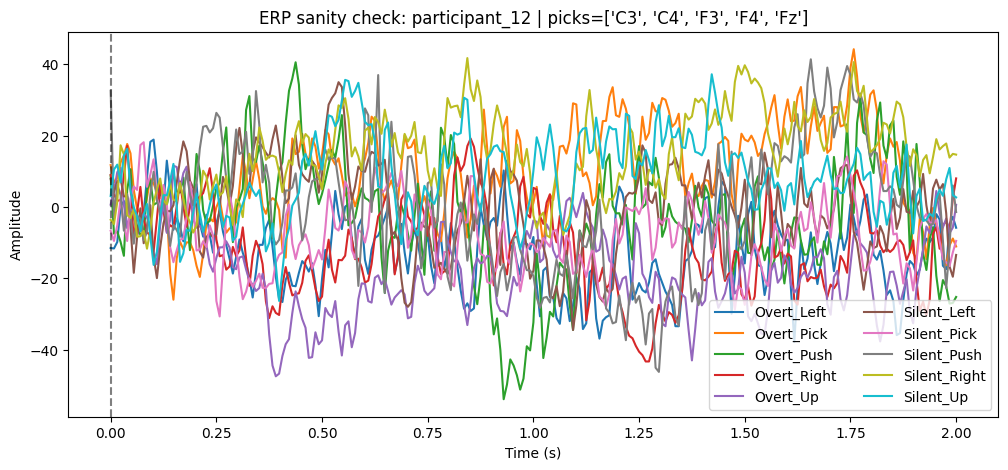

In [11]:
# ERP sanity check: averaged signal over selected channels

def plot_average_erps(epochs, title="Average ERP by event", picks=None):
    if epochs is None or len(epochs) == 0:
        print("No epochs available for ERP plotting.")
        return

    picks = picks or [ch for ch in ["C3", "C4", "CZ", "F3", "F4", "Fz"] if ch in epochs.ch_names]
    if not picks:
        picks = epochs.ch_names[:min(8, len(epochs.ch_names))]

    fig, ax = plt.subplots(figsize=(12, 5))
    times = epochs.times

    for event_name in sorted(set(epochs.event_id.keys())):
        if len(epochs[event_name]) == 0:
            continue
        evk = epochs[event_name].average(picks=picks)
        ax.plot(times, evk.data.mean(axis=0), label=event_name)

    ax.axvline(0, color="k", ls="--", alpha=0.5)
    ax.set_title(title + f" | picks={picks}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.legend(ncol=2)
    plt.show()

if fif_files and epochs0 is not None and len(epochs0) > 0:
    plot_average_erps(epochs0, title=f"ERP sanity check: {subject_id}")
else:
    print("Skipping ERP sanity check because no valid epochs were extracted.")


In [12]:
# Combined epoch build


import tempfile
from pathlib import Path

build_dir = Path(tempfile.mkdtemp(prefix="eeg_build_"))
print("Temporary build dir:", build_dir)

summary_rows = []
usable_infos = []

# ---------- PASS 1: lightweight scan ----------
for path in fif_files:
    sid = infer_subject_id(path)
    try:
        raw_i = load_raw(path)
        X_i, y_i, p_i, meta_i, epochs_i, debug_i = extract_epochs_from_raw(
            raw_i, sid, path, return_debug=True
        )

        ch_names_i = list(epochs_i.ch_names) if epochs_i is not None else []

        summary_rows.append({
            "subject": sid,
            "path": str(path),
            "n_epochs": int(len(y_i)) if y_i is not None else 0,
            "n_channels": len(ch_names_i),
            "commands": sorted(pd.unique(meta_i["command"]).tolist()) if meta_i is not None and not meta_i.empty else [],
            "paradigms": sorted(pd.unique(meta_i["paradigm"]).tolist()) if meta_i is not None and not meta_i.empty else [],
            "event_source": meta_i["event_source"].iloc[0] if meta_i is not None and not meta_i.empty else debug_i.get("event_source", "unknown"),
            "debug_reason": debug_i.get("reason", "unknown"),
        })

        if X_i is not None and len(X_i) > 0 and len(ch_names_i) > 0:
            usable_infos.append({
                "subject": sid,
                "path": str(path),
                "n_epochs": int(len(X_i)),
                "n_times": int(X_i.shape[2]),
                "ch_names": ch_names_i,
            })

        del raw_i, X_i, y_i, p_i, meta_i, epochs_i, debug_i
        gc.collect()
        clear_device_cache()

    except Exception as e:
        summary_rows.append({
            "subject": sid,
            "path": str(path),
            "n_epochs": 0,
            "n_channels": 0,
            "commands": [],
            "paradigms": [],
            "event_source": "skipped",
            "debug_reason": str(e),
        })
        print("Skipping", path, "because:", e)

extraction_df = pd.DataFrame(summary_rows)

if not usable_infos:
    X_all, y_all, paradigm_all, meta_df = None, None, None, None
    print("No epochs were extracted.")
else:
    common_chs = set(usable_infos[0]["ch_names"])
    for info in usable_infos[1:]:
        common_chs &= set(info["ch_names"])
    common_chs = sorted(common_chs)

    if not common_chs:
        raise ValueError("No common EEG channels found across usable subjects.")

    n_times = usable_infos[0]["n_times"]
    np.random.seed(SEED)
    max_per_subject = int(CONFIG.get("max_epochs_per_subject", 500))

    total_rows = sum(min(info["n_epochs"], max_per_subject) for info in usable_infos)

    print("Common channels across usable subjects:", len(common_chs))
    print(common_chs)
    print("Planned total rows after subject capping:", total_rows)

    X_path = build_dir / "X_all.dat"
    X_mem = np.memmap(
        X_path,
        dtype=np.float32,
        mode="w+",
        shape=(total_rows, len(common_chs), n_times),
    )

    y_chunks = []
    p_chunks = []
    meta_chunks = []
    write_pos = 0

    # ---------- PASS 2: reload one subject at a time and write immediately ----------
    for info in usable_infos:
        sid = info["subject"]
        path = Path(info["path"])

        raw_i = load_raw(path)
        X_i, y_i, p_i, meta_i, epochs_i, debug_i = extract_epochs_from_raw(
            raw_i, sid, path, return_debug=True
        )

        ch_names_i = list(epochs_i.ch_names)
        idx = [ch_names_i.index(ch) for ch in common_chs]
        X_i = X_i[:, idx, :]

        keep_n = min(len(X_i), max_per_subject)
        if len(X_i) > keep_n:
            keep_idx = np.random.choice(len(X_i), keep_n, replace=False)
            keep_idx = np.sort(keep_idx)
            X_i = X_i[keep_idx]
            y_i = y_i[keep_idx]
            p_i = p_i[keep_idx]
            meta_i = meta_i.iloc[keep_idx].reset_index(drop=True)

        end_pos = write_pos + len(X_i)
        X_mem[write_pos:end_pos] = X_i
        y_chunks.append(np.asarray(y_i))
        p_chunks.append(np.asarray(p_i))
        meta_chunks.append(meta_i.reset_index(drop=True))
        write_pos = end_pos

        del raw_i, X_i, y_i, p_i, meta_i, epochs_i, debug_i
        gc.collect()
        clear_device_cache()

    X_mem.flush()

    X_all = np.memmap(
        X_path,
        dtype=np.float32,
        mode="r",
        shape=(write_pos, len(common_chs), n_times),
    )
    y_all = np.concatenate(y_chunks, axis=0)
    paradigm_all = np.concatenate(p_chunks, axis=0)
    meta_df = pd.concat(meta_chunks, axis=0).reset_index(drop=True)

    print("Combined X shape:", X_all.shape)
    print("Usable subjects:", meta_df["subject"].nunique())

    display(meta_df.groupby(["paradigm", "command"]).size().rename("n_epochs").reset_index())
    display(meta_df.groupby(["subject", "paradigm"]).size().rename("n_epochs").reset_index())
    display(extraction_df[["subject", "n_epochs", "n_channels", "commands", "paradigms", "event_source", "debug_reason"]])

    print("\nEpoch counts by command:")
    print(meta_df["command"].value_counts())

    print("\nEpoch counts by subject:")
    print(meta_df["subject"].value_counts())


Temporary build dir: /tmp/eeg_build_7h4zpf84
Reading 0 ... 2349839  =      0.000 ...  4699.678 secs...
Reading 0 ... 2406829  =      0.000 ...  4813.658 secs...
Reading 0 ... 2410019  =      0.000 ...  4820.038 secs...
Reading 0 ... 2494959  =      0.000 ...  4989.918 secs...
Reading 0 ... 2591939  =      0.000 ...  5183.878 secs...
Reading 0 ... 2856439  =      0.000 ...  5712.878 secs...
Reading 0 ... 2386609  =      0.000 ...  4773.218 secs...
Reading 0 ... 2309409  =      0.000 ...  4618.818 secs...
Reading 0 ... 2802709  =      0.000 ...  5605.418 secs...
Reading 0 ... 2271519  =      0.000 ...  4543.038 secs...
Reading 0 ... 3121149  =      0.000 ...  6242.298 secs...
Reading 0 ... 2184869  =      0.000 ...  4369.738 secs...
Reading 0 ... 2645439  =      0.000 ...  5290.878 secs...
Reading 0 ... 2078569  =      0.000 ...  4157.138 secs...
Reading 0 ... 3006179  =      0.000 ...  6012.358 secs...
Common channels across usable subjects: 52
['AF3', 'AF4', 'AF7', 'AF8', 'C1', 'C2', '

,paradigm,command,n_epochs
0,imagined,left,441
1,imagined,pick,538
2,imagined,push,364
3,imagined,right,542
4,imagined,up,513
5,overt,left,444
6,overt,pick,584
7,overt,push,448
8,overt,right,418
9,overt,up,562


,subject,paradigm,n_epochs
0,participant_1,imagined,164
1,participant_1,overt,156
2,participant_10,imagined,138
3,participant_10,overt,132
4,participant_11,imagined,113
5,participant_11,overt,86
6,participant_12,imagined,250
7,participant_12,overt,250
8,participant_13,imagined,69
9,participant_13,overt,67


,subject,n_epochs,n_channels,commands,paradigms,event_source,debug_reason
0,participant_1,320,63,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:P5,ok
1,participant_10,270,63,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:T7,ok
2,participant_11,199,63,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:FC1,ok
3,participant_12,500,63,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:FC4,ok
4,participant_13,136,63,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:PO10,ok
5,participant_14,255,64,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:y_dir,ok
6,participant_15,311,63,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:CP1,ok
7,participant_2,228,63,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:PO9,ok
8,participant_3,363,63,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:C3,ok
9,participant_4,425,64,"[left, pick, push, right, up]","[imagined, overt]",channel_scan:x_dir,ok



Epoch counts by command:
command
pick     1122
up       1075
right     960
left      885
push      812
Name: count, dtype: int64

Epoch counts by subject:
subject
participant_12    500
participant_6     500
participant_9     454
participant_4     425
participant_5     422
participant_3     363
participant_1     320
participant_15    311
participant_8     298
participant_10    270
participant_14    255
participant_2     228
participant_11    199
participant_7     173
participant_13    136
Name: count, dtype: int64


In [13]:

# Encode labels

label_encoder = LabelEncoder()
command_names = ["left", "right", "up", "pick", "push"]
label_encoder.fit(command_names)

if y_all is not None:
    y_num = label_encoder.transform(y_all)
    print("Classes:", list(label_encoder.classes_))

Classes: ['left', 'pick', 'push', 'right', 'up']


In [14]:
# Train/val/test split by paradigm

split_ready = False
context_columns = None


def build_context_features(meta, class_names):
    """
    Construct lightweight symbolic-context tensors from metadata.
    This notebook does not include full robot-world state, so the context is limited to:
    - blocked direction flags (default 0, can be replaced later with real robot state)
    - action availability flags for pick/push (default 1)
    - previous command (one-hot within each subject/paradigm stream)
    - paradigm flag (imagined=1, overt=0)
    """
    meta = meta.reset_index(drop=True).copy()
    class_names = list(class_names)

    prev_cmd = []
    last_seen = {}
    for _, row in meta.iterrows():
        key = (row.get("subject", "unknown"), row.get("paradigm", "unknown"))
        prev_cmd.append(last_seen.get(key))
        last_seen[key] = row.get("command")

    ctx = pd.DataFrame(index=meta.index)
    ctx["blocked_left"] = 0.0
    ctx["blocked_right"] = 0.0
    ctx["blocked_up"] = 0.0
    ctx["can_pick"] = 1.0
    ctx["can_push"] = 1.0

    for name in class_names:
        ctx[f"prev_{name}"] = [1.0 if p == name else 0.0 for p in prev_cmd]

    ctx["is_imagined"] = (meta["paradigm"].astype(str).str.lower() == "imagined").astype(float)
    return ctx.astype(np.float32), list(ctx.columns)


if X_all is not None:
    overt_mask = (paradigm_all == "overt")
    imag_mask = (paradigm_all == "imagined")

    X_overt = X_all[overt_mask]
    y_overt = y_num[overt_mask]
    meta_overt = meta_df.loc[overt_mask].reset_index(drop=True)

    X_imag = X_all[imag_mask]
    y_imag = y_num[imag_mask]
    meta_imag = meta_df.loc[imag_mask].reset_index(drop=True)

    print("Overt epochs:", len(y_overt))
    print("Imagined epochs:", len(y_imag))
    print("\nOvert label distribution:")
    display(describe_label_distribution(y_overt, label_encoder))
    print("\nImagined label distribution:")
    display(describe_label_distribution(y_imag, label_encoder))

    if len(y_overt) == 0 or len(y_imag) == 0:
        print("Not enough overt/imagined data to create both splits.")
    else:
        Xo_train, Xo_val, Xo_test, yo_train, yo_val, yo_test, mo_train, mo_val, mo_test = safe_train_val_test_split(
            X_overt, y_overt, meta_overt,
            test_size=CONFIG["test_size"],
            val_size_from_train=CONFIG["val_size_from_train"],
            random_state=SEED,
        )

        Xi_train, Xi_val, Xi_test, yi_train, yi_val, yi_test, mi_train, mi_val, mi_test = safe_train_val_test_split(
            X_imag, y_imag, meta_imag,
            test_size=CONFIG["test_size"],
            val_size_from_train=CONFIG["val_size_from_train"],
            random_state=SEED,
        )

        Xo_train, Xo_val, mu_o, sigma_o = zscore_from_train(Xo_train, Xo_val)
        Xo_train, Xo_test, _, _ = zscore_from_train(Xo_train, Xo_test)

        # For imagined transfer, normalize imagined trials using overt-train statistics.
        Xi_train = (Xi_train - mu_o) / sigma_o
        Xi_val = (Xi_val - mu_o) / sigma_o
        Xi_test = (Xi_test - mu_o) / sigma_o

        Co_train_df, context_columns = build_context_features(mo_train, label_encoder.classes_)
        Co_val_df, _ = build_context_features(mo_val, label_encoder.classes_)
        Co_test_df, _ = build_context_features(mo_test, label_encoder.classes_)

        Ci_train_df, _ = build_context_features(mi_train, label_encoder.classes_)
        Ci_val_df, _ = build_context_features(mi_val, label_encoder.classes_)
        Ci_test_df, _ = build_context_features(mi_test, label_encoder.classes_)

        Co_train = Co_train_df.to_numpy(dtype=np.float32)
        Co_val = Co_val_df.to_numpy(dtype=np.float32)
        Co_test = Co_test_df.to_numpy(dtype=np.float32)
        Ci_train = Ci_train_df.to_numpy(dtype=np.float32)
        Ci_val = Ci_val_df.to_numpy(dtype=np.float32)
        Ci_test = Ci_test_df.to_numpy(dtype=np.float32)

        split_ready = True
        print("Overt train/val/test:", Xo_train.shape, Xo_val.shape, Xo_test.shape)
        print("Imagined train/val/test:", Xi_train.shape, Xi_val.shape, Xi_test.shape)
        print("Context feature dimension:", Co_train.shape[1])
        print("Context columns:", context_columns)

        print("\nOvert train distribution:")
        display(describe_label_distribution(yo_train, label_encoder))
        print("\nImagined train distribution:")
        display(describe_label_distribution(yi_train, label_encoder))


Overt epochs: 2456
Imagined epochs: 2398

Overt label distribution:


,label,count
0,pick,584
1,up,562
2,push,448
3,left,444
4,right,418



Imagined label distribution:


,label,count
0,right,542
1,pick,538
2,up,513
3,left,441
4,push,364


Overt train/val/test: (1571, 52, 257) (393, 52, 257) (492, 52, 257)
Imagined train/val/test: (1534, 52, 257) (384, 52, 257) (480, 52, 257)
Context feature dimension: 11
Context columns: ['blocked_left', 'blocked_right', 'blocked_up', 'can_pick', 'can_push', 'prev_left', 'prev_pick', 'prev_push', 'prev_right', 'prev_up', 'is_imagined']

Overt train distribution:


,label,count
0,pick,374
1,up,360
2,push,286
3,left,284
4,right,267



Imagined train distribution:


,label,count
0,right,347
1,pick,344
2,up,328
3,left,282
4,push,233


In [15]:
# PyTorch dataset helpers

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

class EEGDataset(Dataset):
    def __init__(self, X, y, context=None, augment=False, noise_std=0.02):
        self.X = torch.as_tensor(np.asarray(X), dtype=torch.float32)
        self.y = torch.as_tensor(np.asarray(y), dtype=torch.long)
        self.context = None if context is None else torch.as_tensor(np.asarray(context), dtype=torch.float32)
        self.augment = augment
        self.noise_std = noise_std

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        if self.augment:
            x = x + self.noise_std * torch.randn_like(x)

        if self.context is None:
            return x, y
        return x, y, self.context[idx]


def make_loader(X, y, context=None, shuffle=False, augment=False, sampler=None):
    ds = EEGDataset(X, y, context=context, augment=augment)
    return DataLoader(
        ds,
        batch_size=CONFIG["batch_size"],
        shuffle=(shuffle and sampler is None),
        sampler=sampler,
        num_workers=CONFIG["num_workers"],
        pin_memory=bool(CONFIG["pin_memory"] and DEVICE_TYPE == "cuda"),
        persistent_workers=bool(CONFIG["num_workers"] > 0),
    )



Training model: EEGNet
[EEGNet] epoch=01 train_loss=1.6305 train_bacc=0.2396 val_loss=1.6466 val_bacc=0.2058 val_neural_bacc=0.2058 constraint=0.0000 lr=1.00e-03
[EEGNet] epoch=02 train_loss=1.6069 train_bacc=0.2633 val_loss=1.6323 val_bacc=0.2217 val_neural_bacc=0.2217 constraint=0.0000 lr=1.00e-03
[EEGNet] epoch=03 train_loss=1.5990 train_bacc=0.2779 val_loss=1.6511 val_bacc=0.2049 val_neural_bacc=0.2049 constraint=0.0000 lr=1.00e-03
[EEGNet] epoch=04 train_loss=1.5901 train_bacc=0.2623 val_loss=1.6300 val_bacc=0.2009 val_neural_bacc=0.2009 constraint=0.0000 lr=1.00e-03
[EEGNet] epoch=05 train_loss=1.5976 train_bacc=0.2632 val_loss=1.6325 val_bacc=0.2240 val_neural_bacc=0.2240 constraint=0.0000 lr=1.00e-03
EEGNet -> test_acc=0.1890, test_bacc=0.2109, test_f1_macro=0.1434

Training model: ShallowConvNet
[ShallowConvNet] epoch=01 train_loss=1.6988 train_bacc=0.3148 val_loss=1.8986 val_bacc=0.1760 val_neural_bacc=0.1760 constraint=0.0000 lr=1.00e-03
[ShallowConvNet] epoch=02 train_loss

,model,test_acc,test_bacc,test_f1_macro,best_val_bacc,last_train_bacc,neuro_symbolic_ready
0,ShallowConvNet,0.223577,0.220192,0.180350,0.219146,0.464717,True
1,DeepConvNetLite,0.213415,0.214275,0.187936,0.229874,0.491892,True
2,EEGNet,0.189024,0.210854,0.143386,0.223985,0.263155,True
3,MLPBaseline,0.193089,0.205270,0.173983,0.236513,0.298229,True


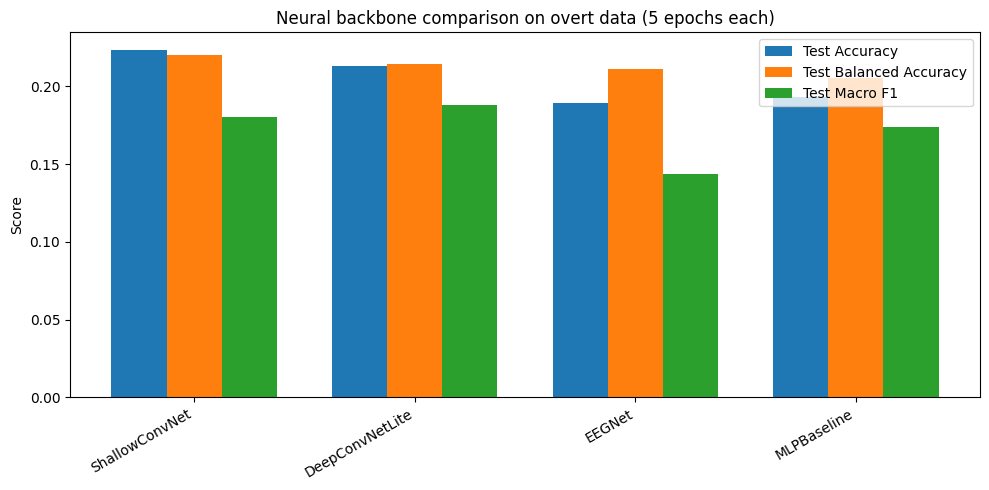

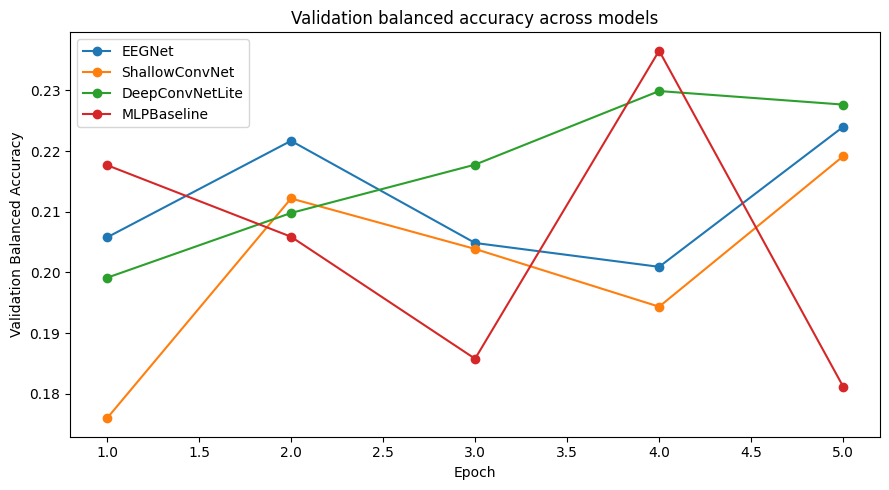

In [42]:
# Compare multiple EEG deep-learning backbones on the current loaded dataset

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

BENCHMARK_EPOCHS = 5


# -------------------------------------------------
# Model zoo
# -------------------------------------------------
class EEGNetBench(nn.Module):
    def __init__(self, n_channels, n_times, n_classes, dropout=0.5):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 25), padding=(0, 12), bias=False),
            nn.BatchNorm2d(16),
        )
        self.depthwise = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=(n_channels, 1), groups=16, bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )
        self.separable = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=(1, 15), padding=(0, 7), groups=16, bias=False),
            nn.Conv2d(16, 32, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, n_channels, n_times)
            feat = self.forward_features(dummy)
            flat_dim = feat.shape[1]
        self.classifier = nn.Linear(flat_dim, n_classes)

    def forward_features(self, x):
        x = x.unsqueeze(1)  # [B,1,C,T]
        x = self.temporal(x)
        x = self.depthwise(x)
        x = self.separable(x)
        x = x.reshape(x.size(0), -1)
        return x

    def forward(self, x):
        return self.classifier(self.forward_features(x))


class ShallowConvNet(nn.Module):
    def __init__(self, n_channels, n_times, n_classes, dropout=0.5):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(1, 20, kernel_size=(1, 25), padding=(0, 12), bias=False),
            nn.Conv2d(20, 20, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(20),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, n_channels, n_times)
            feat = self.forward_features(dummy)
            flat_dim = feat.shape[1]
        self.classifier = nn.Linear(flat_dim, n_classes)

    def forward_features(self, x):
        x = x.unsqueeze(1)
        x = self.block(x)
        x = x.reshape(x.size(0), -1)
        return x

    def forward(self, x):
        return self.classifier(self.forward_features(x))


class DeepConvNetLite(nn.Module):
    def __init__(self, n_channels, n_times, n_classes, dropout=0.5):
        super().__init__()
        self.features_net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 9), padding=(0, 4), bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),

            nn.Conv2d(16, 32, kernel_size=(1, 9), padding=(0, 4), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 2)),
            nn.Dropout(dropout),

            nn.Conv2d(32, 64, kernel_size=(1, 9), padding=(0, 4), bias=False),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.AvgPool2d((1, 2)),
            nn.Dropout(dropout),
        )
        self.spatial = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, n_channels, n_times)
            feat = self.forward_features(dummy)
            flat_dim = feat.shape[1]
        self.classifier = nn.Linear(flat_dim, n_classes)

    def forward_features(self, x):
        x = x.unsqueeze(1)
        x = self.features_net(x)
        x = self.spatial(x)
        x = x.reshape(x.size(0), -1)
        return x

    def forward(self, x):
        return self.classifier(self.forward_features(x))


class MLPBaseline(nn.Module):
    def __init__(self, n_channels, n_times, n_classes, dropout=0.5):
        super().__init__()
        in_dim = n_channels * n_times
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x)


# -------------------------------------------------
# Benchmark runner
# -------------------------------------------------
def benchmark_models(
    model_builders,
    train_loader,
    val_loader,
    test_loader,
    class_weights,
    lr,
    n_epochs=5,
):
    results = []
    histories = {}

    criterion_eval = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE) if class_weights is not None else None,
        label_smoothing=0.1,
    )

    for model_name, builder in model_builders.items():
        print(f"\n{'=' * 80}")
        print(f"Training model: {model_name}")
        print(f"{'=' * 80}")

        clear_device_cache()
        gc.collect()

        model = builder()

        model, hist_df = train_model(
            model,
            train_loader,
            val_loader,
            lr=lr,
            n_epochs=n_epochs,
            class_weights=class_weights,
            title=model_name,
        )

        metrics = evaluate_model(model, test_loader, criterion_eval)

        results.append({
            "model": model_name,
            "test_acc": float(metrics["acc"]),
            "test_bacc": float(metrics["bacc"]),
            "test_f1_macro": float(metrics["f1_macro"]),
            "best_val_bacc": float(hist_df["val_bacc"].max()) if len(hist_df) else np.nan,
            "last_train_bacc": float(hist_df["train_bacc"].iloc[-1]) if len(hist_df) else np.nan,
            "neuro_symbolic_ready": True,
        })
        histories[model_name] = hist_df

        print(
            f"{model_name} -> "
            f"test_acc={metrics['acc']:.4f}, "
            f"test_bacc={metrics['bacc']:.4f}, "
            f"test_f1_macro={metrics['f1_macro']:.4f}"
        )

        del model
        gc.collect()
        clear_device_cache()

    results_df = pd.DataFrame(results).sort_values("test_bacc", ascending=False).reset_index(drop=True)
    return results_df, histories


# -------------------------------------------------
# Run benchmark
# -------------------------------------------------
if X_all is not None and split_ready:
    model_builders = {
        "EEGNet": lambda: EEGNetBench(
            n_channels=n_channels,
            n_times=n_times,
            n_classes=n_classes,
            dropout=CONFIG["dropout"],
        ),
        "ShallowConvNet": lambda: ShallowConvNet(
            n_channels=n_channels,
            n_times=n_times,
            n_classes=n_classes,
            dropout=CONFIG["dropout"],
        ),
        "DeepConvNetLite": lambda: DeepConvNetLite(
            n_channels=n_channels,
            n_times=n_times,
            n_classes=n_classes,
            dropout=CONFIG["dropout"],
        ),
        "MLPBaseline": lambda: MLPBaseline(
            n_channels=n_channels,
            n_times=n_times,
            n_classes=n_classes,
            dropout=CONFIG["dropout"],
        ),
    }

    benchmark_df, benchmark_histories = benchmark_models(
        model_builders=model_builders,
        train_loader=overt_train_loader,
        val_loader=overt_val_loader,
        test_loader=overt_test_loader,
        class_weights=overt_class_weights,
        lr=CONFIG["lr_overt"],
        n_epochs=BENCHMARK_EPOCHS,
    )

    print("\n=== MODEL COMPARISON TABLE ===")
    display(benchmark_df)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(benchmark_df))
    width = 0.25

    ax.bar(x - width, benchmark_df["test_acc"], width=width, label="Test Accuracy")
    ax.bar(x, benchmark_df["test_bacc"], width=width, label="Test Balanced Accuracy")
    ax.bar(x + width, benchmark_df["test_f1_macro"], width=width, label="Test Macro F1")

    ax.set_xticks(x)
    ax.set_xticklabels(benchmark_df["model"], rotation=30, ha="right")
    ax.set_ylabel("Score")
    ax.set_title(f"Neural backbone comparison on overt data ({BENCHMARK_EPOCHS} epochs each)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    for model_name, hist_df in benchmark_histories.items():
        if len(hist_df):
            ax.plot(hist_df["epoch"], hist_df["val_bacc"], marker="o", label=model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Balanced Accuracy")
    ax.set_title("Validation balanced accuracy across models")
    ax.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Benchmark skipped because dataset splits/loaders are not ready.")

In [16]:
# End-to-end neuro-symbolic model
# EEG -> Neural encoder -> Differentiable symbol extraction -> Learnable symbolic layer -> Final prediction

class EEGEncoder(nn.Module):
    def __init__(self, n_channels, n_times, dropout=0.5):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=(1, 25), padding=(0, 12), bias=False),
            nn.BatchNorm2d(12),
        )
        self.depthwise = nn.Sequential(
            nn.Conv2d(12, 12, kernel_size=(n_channels, 1), groups=12, bias=False),
            nn.BatchNorm2d(12),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )
        self.separable = nn.Sequential(
            nn.Conv2d(12, 12, kernel_size=(1, 15), padding=(0, 7), groups=12, bias=False),
            nn.Conv2d(12, 24, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(24),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, n_channels, n_times)
            feat = self.forward(dummy)
            self.out_dim = feat.shape[1]

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.temporal(x)
        x = self.depthwise(x)
        x = self.separable(x)
        x = x.reshape(x.size(0), -1)
        return x


class LearnableNeuroSymbolicLayer(nn.Module):
    def __init__(self, class_names, min_conf=0.35, invalid_init=1.25, repeat_init=0.35, feasible_boost_init=0.20, gate_sharpness_init=8.0):
        super().__init__()
        self.class_names = list(class_names)
        self.class_to_idx = {name: i for i, name in enumerate(self.class_names)}
        self.n_classes = len(self.class_names)
        self.min_conf = float(min_conf)
        self.invalid_weight = nn.Parameter(torch.full((self.n_classes,), float(invalid_init)))
        self.repeat_weight = nn.Parameter(torch.full((self.n_classes,), float(repeat_init)))
        self.feasible_boost = nn.Parameter(torch.full((self.n_classes,), float(feasible_boost_init)))
        self.imagined_bias = nn.Parameter(torch.zeros(self.n_classes))
        self.gate_sharpness = nn.Parameter(torch.tensor(float(gate_sharpness_init)))

    def _compute_terms(self, neural_probs, context):
        eps = 1e-6
        B = neural_probs.shape[0]
        device = neural_probs.device
        dtype = neural_probs.dtype

        if context is None:
            context = torch.zeros(B, 5 + self.n_classes + 1, device=device, dtype=dtype)
            context[:, 3] = 1.0  # can_pick
            context[:, 4] = 1.0  # can_push
        else:
            context = context.to(device=device, dtype=dtype)

        invalid_mask = torch.zeros_like(neural_probs)
        if "left" in self.class_to_idx:
            invalid_mask[:, self.class_to_idx["left"]] = context[:, 0]
        if "right" in self.class_to_idx:
            invalid_mask[:, self.class_to_idx["right"]] = context[:, 1]
        if "up" in self.class_to_idx:
            invalid_mask[:, self.class_to_idx["up"]] = context[:, 2]
        if "pick" in self.class_to_idx:
            invalid_mask[:, self.class_to_idx["pick"]] = 1.0 - context[:, 3]
        if "push" in self.class_to_idx:
            invalid_mask[:, self.class_to_idx["push"]] = 1.0 - context[:, 4]

        prev_start = 5
        prev_end = prev_start + self.n_classes
        prev_onehot = context[:, prev_start:prev_end]
        is_imagined = context[:, prev_end:prev_end + 1]

        max_conf, _ = neural_probs.max(dim=1, keepdim=True)
        entropy = -(neural_probs * (neural_probs + eps).log()).sum(dim=1, keepdim=True)
        entropy = entropy / np.log(self.n_classes)
        gate_sharpness = F.softplus(self.gate_sharpness) + 1e-4
        low_conf_gate = torch.sigmoid((self.min_conf - max_conf) * gate_sharpness)
        uncertainty = 0.5 * (1.0 - max_conf) + 0.5 * entropy

        invalid_penalty = F.softplus(self.invalid_weight).unsqueeze(0) * invalid_mask
        repeat_penalty = F.softplus(self.repeat_weight).unsqueeze(0) * prev_onehot * uncertainty
        feasible_boost = F.softplus(self.feasible_boost).unsqueeze(0) * (1.0 - invalid_mask) * low_conf_gate
        imagined_bias = is_imagined * self.imagined_bias.unsqueeze(0)

        adjusted_logits = torch.log(neural_probs + eps) - invalid_penalty - repeat_penalty + feasible_boost + imagined_bias
        adjusted_probs = torch.softmax(adjusted_logits, dim=1)

        invalid_mass = (adjusted_probs * invalid_mask).sum(dim=1)
        repeat_mass = (adjusted_probs * prev_onehot).sum(dim=1)
        constraint_loss = (invalid_mass + 0.25 * low_conf_gate.squeeze(1) * repeat_mass).mean()

        return {
            "adjusted_logits": adjusted_logits,
            "adjusted_probs": adjusted_probs,
            "invalid_mask": invalid_mask,
            "prev_onehot": prev_onehot,
            "max_conf": max_conf,
            "entropy": entropy,
            "low_conf_gate": low_conf_gate,
            "uncertainty": uncertainty,
            "invalid_penalty": invalid_penalty,
            "repeat_penalty": repeat_penalty,
            "feasible_boost_term": feasible_boost,
            "imagined_bias_term": imagined_bias,
            "constraint_loss": constraint_loss,
        }

    def forward(self, neural_logits, context=None):
        neural_probs = torch.softmax(neural_logits, dim=1)
        terms = self._compute_terms(neural_probs, context)
        terms.update({
            "neural_logits": neural_logits,
            "neural_probs": neural_probs,
            "candidate_symbols": neural_probs,
        })
        return terms


class EndToEndNeuroSymbolicEEGNet(nn.Module):
    def __init__(self, n_channels, n_times, n_classes, class_names, dropout=0.5, min_conf=0.35,
                 invalid_init=1.25, repeat_init=0.35, feasible_boost_init=0.20, gate_sharpness_init=8.0):
        super().__init__()
        self.encoder = EEGEncoder(n_channels=n_channels, n_times=n_times, dropout=dropout)
        self.classifier = nn.Linear(self.encoder.out_dim, n_classes)
        self.symbolic_layer = LearnableNeuroSymbolicLayer(
            class_names=class_names,
            min_conf=min_conf,
            invalid_init=invalid_init,
            repeat_init=repeat_init,
            feasible_boost_init=feasible_boost_init,
            gate_sharpness_init=gate_sharpness_init,
        )

    def forward(self, x, context=None):
        feat = self.encoder(x)
        neural_logits = self.classifier(feat)
        outputs = self.symbolic_layer(neural_logits, context=context)
        outputs["features"] = feat
        return outputs


In [17]:
# Training and evaluation utilities


def unpack_batch(batch):
    if isinstance(batch, (list, tuple)) and len(batch) == 3:
        xb, yb, cb = batch
    elif isinstance(batch, (list, tuple)) and len(batch) == 2:
        xb, yb = batch
        cb = None
    else:
        raise ValueError("Unexpected batch format.")
    return xb, yb, cb



def move_batch_to_device(xb, yb, cb=None):
    xb = xb.to(DEVICE, non_blocking=CONFIG["non_blocking_transfer"])
    yb = yb.to(DEVICE, non_blocking=CONFIG["non_blocking_transfer"])
    if cb is not None:
        cb = cb.to(DEVICE, non_blocking=CONFIG["non_blocking_transfer"])
    return xb, yb, cb



def run_model_forward(model, xb, cb=None):
    try:
        outputs = model(xb, cb)
    except TypeError:
        outputs = model(xb)

    if isinstance(outputs, dict):
        return outputs

    logits = outputs
    probs = torch.softmax(logits, dim=1)
    return {
        "neural_logits": logits,
        "neural_probs": probs,
        "adjusted_logits": logits,
        "adjusted_probs": probs,
        "constraint_loss": torch.tensor(0.0, device=logits.device),
    }



def compute_total_loss(outputs, yb, criterion, constraint_weight=0.0):
    task_loss = criterion(outputs["adjusted_logits"], yb)
    constraint_term = outputs.get("constraint_loss", None)
    if constraint_term is None:
        constraint_term = torch.tensor(0.0, device=task_loss.device)
    total_loss = task_loss + float(constraint_weight) * constraint_term
    return total_loss, task_loss.detach(), constraint_term.detach()



def evaluate_model(model, loader, criterion, constraint_weight=0.0):
    model.eval()
    all_probs, all_pred, all_true = [], [], []
    all_neural_probs, all_neural_pred = [], []
    total_loss = 0.0
    total_task_loss = 0.0
    total_constraint = 0.0
    total_n = 0

    with torch.no_grad():
        for batch in loader:
            xb, yb, cb = unpack_batch(batch)
            xb, yb, cb = move_batch_to_device(xb, yb, cb)
            outputs = run_model_forward(model, xb, cb)
            loss, task_loss, constraint_loss = compute_total_loss(outputs, yb, criterion, constraint_weight=constraint_weight)

            probs = outputs["adjusted_probs"]
            pred = torch.argmax(probs, dim=1)
            neural_probs = outputs.get("neural_probs", probs)
            neural_pred = torch.argmax(neural_probs, dim=1)

            total_loss += loss.item() * len(yb)
            total_task_loss += task_loss.item() * len(yb)
            total_constraint += constraint_loss.item() * len(yb)
            total_n += len(yb)

            all_probs.append(probs.detach().cpu().numpy())
            all_pred.append(pred.detach().cpu().numpy())
            all_true.append(yb.detach().cpu().numpy())
            all_neural_probs.append(neural_probs.detach().cpu().numpy())
            all_neural_pred.append(neural_pred.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    probs = np.concatenate(all_probs)
    neural_probs = np.concatenate(all_neural_probs)
    neural_pred = np.concatenate(all_neural_pred)

    metrics = {
        "loss": total_loss / max(total_n, 1),
        "task_loss": total_task_loss / max(total_n, 1),
        "constraint_loss": total_constraint / max(total_n, 1),
        "acc": accuracy_score(y_true, y_pred),
        "bacc": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "neural_acc": accuracy_score(y_true, neural_pred),
        "neural_bacc": balanced_accuracy_score(y_true, neural_pred),
        "y_true": y_true,
        "y_pred": y_pred,
        "probs": probs,
        "neural_probs": neural_probs,
        "neural_pred": neural_pred,
    }
    return metrics



def train_model(model, train_loader, val_loader, lr, n_epochs, class_weights=None, title="model", constraint_weight=None):
    model = model.to(DEVICE)
    if constraint_weight is None:
        constraint_weight = CONFIG.get("constraint_loss_weight", 0.0)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE) if class_weights is not None else None,
        label_smoothing=0.1,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=CONFIG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=3,
        factor=0.5,
    )

    history = []
    best_state = None
    best_bacc = -np.inf
    patience = 6
    bad_epochs = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss = 0.0
        total_n = 0

        for batch in train_loader:
            xb, yb, cb = unpack_batch(batch)
            xb, yb, cb = move_batch_to_device(xb, yb, cb)
            optimizer.zero_grad(set_to_none=True)
            outputs = run_model_forward(model, xb, cb)
            loss, _, _ = compute_total_loss(outputs, yb, criterion, constraint_weight=constraint_weight)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            total_loss += loss.item() * len(yb)
            total_n += len(yb)

        train_loss = total_loss / max(total_n, 1)
        train_metrics = evaluate_model(model, train_loader, criterion, constraint_weight=constraint_weight)
        val_metrics = evaluate_model(model, val_loader, criterion, constraint_weight=constraint_weight)
        scheduler.step(val_metrics["bacc"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_metrics["acc"],
            "train_bacc": train_metrics["bacc"],
            "train_neural_bacc": train_metrics["neural_bacc"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_bacc": val_metrics["bacc"],
            "val_neural_bacc": val_metrics["neural_bacc"],
            "val_constraint_loss": val_metrics["constraint_loss"],
            "val_f1_macro": val_metrics["f1_macro"],
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        if val_metrics["bacc"] > best_bacc:
            best_bacc = val_metrics["bacc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(
            f"[{title}] epoch={epoch:02d} "
            f"train_loss={train_loss:.4f} train_bacc={train_metrics['bacc']:.4f} "
            f"val_loss={val_metrics['loss']:.4f} val_bacc={val_metrics['bacc']:.4f} "
            f"val_neural_bacc={val_metrics['neural_bacc']:.4f} "
            f"constraint={val_metrics['constraint_loss']:.4f} "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        clear_device_cache()

        if bad_epochs >= patience:
            print(f"[{title}] early stopping triggered at epoch {epoch}")
            break

    hist_df = pd.DataFrame(history)
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, hist_df



def plot_history(hist_df, title="training history"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val")
    axes[0].set_title(title + " - loss")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["train_bacc"], label="train final")
    axes[1].plot(hist_df["epoch"], hist_df["val_bacc"], label="val final")
    if "val_neural_bacc" in hist_df:
        axes[1].plot(hist_df["epoch"], hist_df["val_neural_bacc"], label="val neural", linestyle="--")
    axes[1].set_title(title + " - balanced accuracy")
    axes[1].legend()
    plt.show()


In [18]:
# Build loaders and compute class weights

from sklearn.utils.class_weight import compute_class_weight

if X_all is not None and split_ready:
    n_channels = Xo_train.shape[1]
    n_times = Xo_train.shape[2]
    n_classes = len(label_encoder.classes_)
    context_dim = Co_train.shape[1]

    overt_classes = np.unique(yo_train)
    overt_weights_np = compute_class_weight(
        class_weight="balanced",
        classes=overt_classes,
        y=yo_train,
    )
    overt_class_weights = torch.ones(n_classes, dtype=torch.float32)
    overt_class_weights[overt_classes] = torch.tensor(overt_weights_np, dtype=torch.float32)

    imag_classes = np.unique(yi_train)
    imag_weights_np = compute_class_weight(
        class_weight="balanced",
        classes=imag_classes,
        y=yi_train,
    )
    imag_class_weights = torch.ones(n_classes, dtype=torch.float32)
    imag_class_weights[imag_classes] = torch.tensor(imag_weights_np, dtype=torch.float32)

    class_count = np.bincount(yo_train, minlength=n_classes)
    sample_weights = 1.0 / np.maximum(class_count[yo_train], 1)
    overt_sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

    overt_train_loader = make_loader(Xo_train, yo_train, context=Co_train, shuffle=False, augment=True, sampler=overt_sampler)
    overt_val_loader = make_loader(Xo_val, yo_val, context=Co_val, shuffle=False, augment=False)
    overt_test_loader = make_loader(Xo_test, yo_test, context=Co_test, shuffle=False, augment=False)

    imag_train_loader = make_loader(Xi_train, yi_train, context=Ci_train, shuffle=True, augment=True)
    imag_val_loader = make_loader(Xi_val, yi_val, context=Ci_val, shuffle=False, augment=False)
    imag_test_loader = make_loader(Xi_test, yi_test, context=Ci_test, shuffle=False, augment=False)

    print("n_channels:", n_channels, "n_times:", n_times, "n_classes:", n_classes, "context_dim:", context_dim)
    print("Overt:", len(y_overt))
    print("Imag:", len(y_imag))
    print("overt class counts:", np.bincount(yo_train, minlength=n_classes))
    print("imagined class counts:", np.bincount(yi_train, minlength=n_classes))
    print("overt class weights:", overt_class_weights)
    print("imagined class weights:", imag_class_weights)
else:
    print("Loaders were not created because the dataset splits are not ready.")


n_channels: 52 n_times: 257 n_classes: 5 context_dim: 11
Overt: 2456
Imag: 2398
overt class counts: [284 374 286 267 360]
imagined class counts: [282 344 233 347 328]
overt class weights: tensor([1.1063, 0.8401, 1.0986, 1.1768, 0.8728])
imagined class weights: tensor([1.0879, 0.8919, 1.3167, 0.8841, 0.9354])


[overt_end_to_end_neurosymbolic] epoch=01 train_loss=1.6818 train_bacc=0.2269 val_loss=1.6805 val_bacc=0.2141 val_neural_bacc=0.2292 constraint=0.0173 lr=1.00e-03
[overt_end_to_end_neurosymbolic] epoch=02 train_loss=1.6453 train_bacc=0.2395 val_loss=1.7043 val_bacc=0.1883 val_neural_bacc=0.2239 constraint=0.0172 lr=1.00e-03
[overt_end_to_end_neurosymbolic] epoch=03 train_loss=1.6337 train_bacc=0.2992 val_loss=1.6917 val_bacc=0.2005 val_neural_bacc=0.2123 constraint=0.0178 lr=1.00e-03
[overt_end_to_end_neurosymbolic] epoch=04 train_loss=1.6035 train_bacc=0.3159 val_loss=1.6852 val_bacc=0.2082 val_neural_bacc=0.2379 constraint=0.0175 lr=1.00e-03
[overt_end_to_end_neurosymbolic] epoch=05 train_loss=1.5942 train_bacc=0.2852 val_loss=1.6770 val_bacc=0.1937 val_neural_bacc=0.2123 constraint=0.0176 lr=5.00e-04
[overt_end_to_end_neurosymbolic] epoch=06 train_loss=1.5826 train_bacc=0.3182 val_loss=1.7103 val_bacc=0.2168 val_neural_bacc=0.2197 constraint=0.0174 lr=5.00e-04
[overt_end_to_end_neur

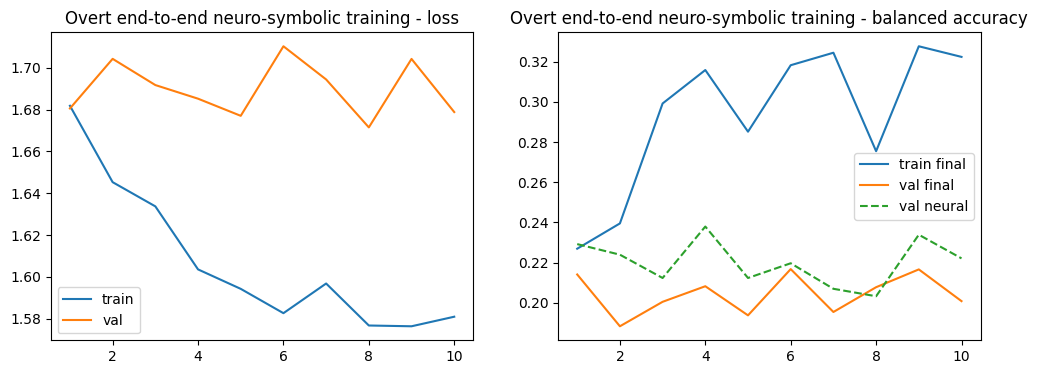

In [21]:
# Stage 1: train the end-to-end neuro-symbolic model on overt data

if X_all is not None and split_ready:
    overt_model = EndToEndNeuroSymbolicEEGNet(
        n_channels=n_channels,
        n_times=n_times,
        n_classes=n_classes,
        class_names=label_encoder.classes_,
        dropout=CONFIG["dropout"],
        min_conf=CONFIG["symbolic_min_confidence"],
        invalid_init=CONFIG["invalid_rule_init"],
        repeat_init=CONFIG["repeat_rule_init"],
        feasible_boost_init=CONFIG["feasible_boost_init"],
        gate_sharpness_init=CONFIG["gate_sharpness_init"],
    )
    overt_model, overt_hist = train_model(
        overt_model,
        overt_train_loader,
        overt_val_loader,
        lr=CONFIG["lr_overt"],
        n_epochs=CONFIG["epochs_overt"],
        class_weights=overt_class_weights,
        title="overt_end_to_end_neurosymbolic",
        constraint_weight=CONFIG["constraint_loss_weight"],
    )
    plot_history(overt_hist, title="Overt end-to-end neuro-symbolic training")
else:
    print("Overt training skipped because splits/loaders are not ready.")


In [22]:
# Overt evaluation

if X_all is not None and split_ready:
    criterion_tmp = nn.CrossEntropyLoss(
        weight=overt_class_weights.to(DEVICE),
        label_smoothing=0.1,
    )
    overt_test_metrics = evaluate_model(
        overt_model,
        overt_test_loader,
        criterion_tmp,
        constraint_weight=CONFIG["constraint_loss_weight"],
    )
    print("Overt neural-only acc :", round(overt_test_metrics["neural_acc"], 4))
    print("Overt neural-only bacc:", round(overt_test_metrics["neural_bacc"], 4))
    print("Overt final acc       :", round(overt_test_metrics["acc"], 4))
    print("Overt final bacc      :", round(overt_test_metrics["bacc"], 4))
    print("Overt final f1m       :", round(overt_test_metrics["f1_macro"], 4))
    print("Overt constraint loss :", round(overt_test_metrics["constraint_loss"], 4))
    print()
    print("Classification report (final neuro-symbolic predictions):")
    print(classification_report(
        overt_test_metrics["y_true"],
        overt_test_metrics["y_pred"],
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0,
    ))
else:
    print("Overt evaluation skipped because training was not run.")


Overt neural-only acc : 0.2317
Overt neural-only bacc: 0.216
Overt final acc       : 0.2317
Overt final bacc      : 0.216
Overt final f1m       : 0.1646
Overt constraint loss : 0.0006

Classification report (final neuro-symbolic predictions):
              precision    recall  f1-score   support

        left     0.2500    0.2697    0.2595        89
        pick     0.4783    0.0940    0.1571       117
        push     0.1667    0.0111    0.0208        90
       right     0.1154    0.0357    0.0545        84
          up     0.2199    0.6696    0.3311       112

    accuracy                         0.2317       492
   macro avg     0.2461    0.2160    0.1646       492
weighted avg     0.2592    0.2317    0.1728       492



[imagined_transfer_end_to_end_neurosymbolic] epoch=01 train_loss=1.7065 train_bacc=0.2073 val_loss=1.6968 val_bacc=0.1959 val_neural_bacc=0.1794 constraint=0.0183 lr=3.00e-04
[imagined_transfer_end_to_end_neurosymbolic] epoch=02 train_loss=1.6767 train_bacc=0.2250 val_loss=1.6816 val_bacc=0.1966 val_neural_bacc=0.1875 constraint=0.0187 lr=3.00e-04
[imagined_transfer_end_to_end_neurosymbolic] epoch=03 train_loss=1.6631 train_bacc=0.2419 val_loss=1.6824 val_bacc=0.1912 val_neural_bacc=0.1928 constraint=0.0188 lr=3.00e-04
[imagined_transfer_end_to_end_neurosymbolic] epoch=04 train_loss=1.6532 train_bacc=0.2502 val_loss=1.6786 val_bacc=0.1783 val_neural_bacc=0.1753 constraint=0.0189 lr=3.00e-04
[imagined_transfer_end_to_end_neurosymbolic] epoch=05 train_loss=1.6472 train_bacc=0.2606 val_loss=1.6773 val_bacc=0.1931 val_neural_bacc=0.1804 constraint=0.0191 lr=3.00e-04
[imagined_transfer_end_to_end_neurosymbolic] epoch=06 train_loss=1.6353 train_bacc=0.2662 val_loss=1.6804 val_bacc=0.1755 val

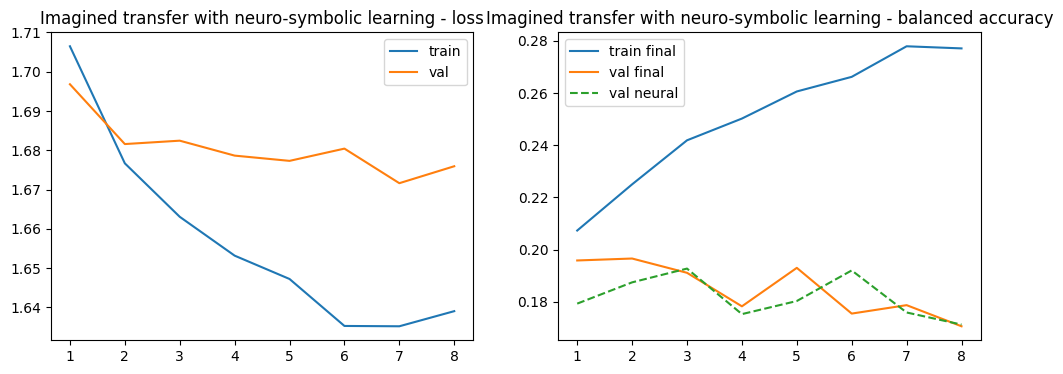

In [23]:
# Stage 2: transfer to imagined data

if X_all is not None and split_ready:
    transfer_model = EndToEndNeuroSymbolicEEGNet(
        n_channels=n_channels,
        n_times=n_times,
        n_classes=n_classes,
        class_names=label_encoder.classes_,
        dropout=CONFIG["dropout"],
        min_conf=CONFIG["symbolic_min_confidence"],
        invalid_init=CONFIG["invalid_rule_init"],
        repeat_init=CONFIG["repeat_rule_init"],
        feasible_boost_init=CONFIG["feasible_boost_init"],
        gate_sharpness_init=CONFIG["gate_sharpness_init"],
    ).to(DEVICE)
    transfer_model.load_state_dict(overt_model.state_dict())

    if CONFIG["freeze_feature_extractor_during_transfer"]:
        for name, param in transfer_model.named_parameters():
            if "classifier" not in name and "symbolic_layer" not in name:
                param.requires_grad = False

    transfer_model, transfer_hist = train_model(
        transfer_model,
        imag_train_loader,
        imag_val_loader,
        lr=CONFIG["lr_imagined"],
        n_epochs=CONFIG["epochs_imagined"],
        class_weights=imag_class_weights,
        title="imagined_transfer_end_to_end_neurosymbolic",
        constraint_weight=CONFIG["constraint_loss_weight"],
    )
    plot_history(transfer_hist, title="Imagined transfer with neuro-symbolic learning")
else:
    print("Imagined transfer skipped because training was not run.")


In [24]:
# Imagined evaluation

if X_all is not None and split_ready:
    criterion_tmp = nn.CrossEntropyLoss(
        weight=imag_class_weights.to(DEVICE),
        label_smoothing=0.1,
    )
    imag_test_metrics = evaluate_model(
        transfer_model,
        imag_test_loader,
        criterion_tmp,
        constraint_weight=CONFIG["constraint_loss_weight"],
    )
    print("Imagined neural-only acc :", round(imag_test_metrics["neural_acc"], 4))
    print("Imagined neural-only bacc:", round(imag_test_metrics["neural_bacc"], 4))
    print("Imagined final acc       :", round(imag_test_metrics["acc"], 4))
    print("Imagined final bacc      :", round(imag_test_metrics["bacc"], 4))
    print("Imagined final f1m       :", round(imag_test_metrics["f1_macro"], 4))
    print("Imagined constraint loss :", round(imag_test_metrics["constraint_loss"], 4))
    print()
    print("Classification report (final neuro-symbolic predictions):")
    print(classification_report(
        imag_test_metrics["y_true"],
        imag_test_metrics["y_pred"],
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0,
    ))
else:
    print("Imagined evaluation skipped because transfer was not run.")


Imagined neural-only acc : 0.1646
Imagined neural-only bacc: 0.1874
Imagined final acc       : 0.1542
Imagined final bacc      : 0.1737
Imagined final f1m       : 0.1256
Imagined constraint loss : 0.0189

Classification report (final neuro-symbolic predictions):
              precision    recall  f1-score   support

        left     0.1200    0.0682    0.0870        88
        pick     0.0645    0.0185    0.0288       108
        push     0.1418    0.5205    0.2229        73
       right     0.2353    0.2222    0.2286       108
          up     0.1379    0.0388    0.0606       103

    accuracy                         0.1542       480
   macro avg     0.1399    0.1737    0.1256       480
weighted avg     0.1406    0.1542    0.1207       480



In [36]:
# Symbol extraction, learnable symbolic rules and explanation utilities

@dataclass
class SymbolicTraceResult:
    neural_decision: str
    final_decision: str
    neural_confidence: float
    final_confidence: float
    neural_probs: dict
    final_probs: dict
    fired_rules: list
    notes: list
    explanation_text: str
    decision_changed: bool


def context_row_to_tensor(row_df):
    return torch.as_tensor(row_df.to_numpy(dtype=np.float32), dtype=torch.float32)


def _prob_dict(class_names, values):
    return {k: round(float(v), 4) for k, v in zip(class_names, values)}


def _top_labels(class_names, values, k=2):
    order = np.argsort(values)[::-1][:k]
    return [(class_names[i], float(values[i])) for i in order]


def _safe_context_map(context_columns, context_vec):
    return {str(k): float(v) for k, v in zip(context_columns, context_vec)}


from types import SimpleNamespace

from types import SimpleNamespace

def explain_single_prediction(model, probs, context_vec, class_names, context_columns):
    layer = model.symbolic_layer if hasattr(model, "symbolic_layer") else model.neuro_symbolic

    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = DEVICE

    neural_probs = torch.as_tensor(
        probs, dtype=torch.float32, device=device
    ).unsqueeze(0)

    context_tensor = torch.as_tensor(
        context_vec, dtype=torch.float32, device=device
    ).unsqueeze(0)

    with torch.no_grad():
        terms = layer._compute_terms(neural_probs, context_tensor)

    adjusted_probs = terms["adjusted_probs"][0].detach().cpu().numpy()
    neural_probs_np = neural_probs[0].detach().cpu().numpy()

    invalid_mask = terms["invalid_mask"][0].detach().cpu().numpy() if "invalid_mask" in terms else None
    repeat_match = terms["repeat_match"][0].detach().cpu().numpy() if "repeat_match" in terms else None
    invalid_penalty = terms["invalid_penalty"][0].detach().cpu().numpy() if "invalid_penalty" in terms else None
    repeat_penalty = terms["repeat_penalty"][0].detach().cpu().numpy() if "repeat_penalty" in terms else None
    feasible_boost_term = terms["feasible_boost_term"][0].detach().cpu().numpy() if "feasible_boost_term" in terms else None
    imagined_bias_term = terms["imagined_bias_term"][0].detach().cpu().numpy() if "imagined_bias_term" in terms else None
    low_conf_gate = float(terms["low_conf_gate"][0].detach().cpu().item()) if "low_conf_gate" in terms else None

    neural_idx = int(np.argmax(neural_probs_np))
    final_idx = int(np.argmax(adjusted_probs))

    neural_decision = class_names[neural_idx]
    final_decision = class_names[final_idx]
    neural_conf = float(neural_probs_np[neural_idx])
    final_conf = float(adjusted_probs[final_idx])
    decision_changed = neural_idx != final_idx

    fired_rules = []
    notes = []

    for i, cls in enumerate(class_names):
        cls_name = str(cls).upper()

        if invalid_mask is not None and invalid_penalty is not None:
            if invalid_mask[i] > 0.5 and invalid_penalty[i] > 1e-6:
                rule = f"{cls_name} was penalized because it violated a symbolic constraint."
                fired_rules.append(rule)
                notes.append(rule)

        if repeat_match is not None and repeat_penalty is not None:
            if repeat_match[i] > 0.5 and repeat_penalty[i] > 1e-6:
                rule = f"{cls_name} was penalized because it repeated the previous command."
                fired_rules.append(rule)
                notes.append(rule)

        if feasible_boost_term is not None and feasible_boost_term[i] > 1e-6:
            rule = f"{cls_name} received a feasibility boost from the symbolic layer."
            fired_rules.append(rule)
            notes.append(rule)

        if imagined_bias_term is not None and abs(imagined_bias_term[i]) > 1e-6:
            if imagined_bias_term[i] > 0:
                rule = f"{cls_name} was increased by the imagined-paradigm symbolic bias."
            else:
                rule = f"{cls_name} was decreased by the imagined-paradigm symbolic bias."
            fired_rules.append(rule)
            notes.append(rule)

    if low_conf_gate is not None and low_conf_gate > 0.5:
        notes.append("The symbolic layer became more active because the neural confidence was low.")

    if decision_changed:
        notes.append(
            f"The neural model initially preferred {str(neural_decision).upper()}, but symbolic reasoning changed the final output to {str(final_decision).upper()}."
        )
    else:
        notes.append(
            f"The final output remained {str(final_decision).upper()} because it stayed the most supported valid command."
        )

    # remove duplicates while preserving order
    fired_rules = list(dict.fromkeys(fired_rules))
    notes = list(dict.fromkeys(notes))
    explanation_text = " ".join(notes)

    return SimpleNamespace(
        neural_decision=neural_decision,
        final_decision=final_decision,
        neural_confidence=neural_conf,
        final_confidence=final_conf,
        decision_changed=decision_changed,
        fired_rules=fired_rules,
        explanation_text=explanation_text,
        neural_probs=neural_probs_np,
        final_probs=adjusted_probs,
        notes=notes,
        explanation=explanation_text,
    )

    layer = model.symbolic_layer
    neural_probs = torch.as_tensor(probs, dtype=torch.float32).unsqueeze(0)
    context_tensor = torch.as_tensor(context_vec, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        terms = layer._compute_terms(neural_probs, context_tensor)

    adjusted_probs = terms["adjusted_probs"][0].detach().cpu().numpy()
    invalid_mask = terms["invalid_mask"][0].detach().cpu().numpy()
    prev_onehot = terms["prev_onehot"][0].detach().cpu().numpy()
    invalid_penalty = terms.get("invalid_penalty", torch.zeros_like(terms["adjusted_probs"]))[0].detach().cpu().numpy()
    repeat_penalty = terms.get("repeat_penalty", torch.zeros_like(terms["adjusted_probs"]))[0].detach().cpu().numpy()
    feasible_boost = terms.get("feasible_boost_term", torch.zeros_like(terms["adjusted_probs"]))[0].detach().cpu().numpy()
    imagined_bias = terms.get("imagined_bias_term", torch.zeros_like(terms["adjusted_probs"]))[0].detach().cpu().numpy()
    low_conf_gate = float(terms["low_conf_gate"][0].detach().cpu().item())
    entropy = float(terms["entropy"][0].detach().cpu().item())
    max_conf = float(terms["max_conf"][0].detach().cpu().item())

    neural_idx = int(np.argmax(probs))
    final_idx = int(np.argmax(adjusted_probs))
    neural_decision = class_names[neural_idx]
    final_decision = class_names[final_idx]

    ctx_map = _safe_context_map(context_columns, context_vec)
    fired_rules = []
    notes = []

    # Rule extraction from actual symbolic terms
    blocked_msgs = {
        "left": "LEFT was penalized because the context marked the left direction as blocked.",
        "right": "RIGHT was penalized because the context marked the right direction as blocked.",
        "up": "UP was penalized because the context marked the upward direction as blocked.",
        "pick": "PICK was penalized because picking was unavailable in the current context.",
        "push": "PUSH was penalized because pushing was unavailable in the current context.",
    }
    for i, cls in enumerate(class_names):
        cname = str(cls).lower()
        if invalid_penalty[i] > 1e-6:
            fired_rules.append(blocked_msgs.get(cname, f"{cls.upper()} was penalized by an invalid-action constraint."))
        if repeat_penalty[i] > 1e-6:
            fired_rules.append(
                f"{cls.upper()} received a repetition penalty because it matched the previous command context."
            )
        if feasible_boost[i] > 1e-6 and invalid_mask[i] < 0.5:
            fired_rules.append(
                f"{cls.upper()} received a feasibility boost because the neural confidence was low and the action remained valid."
            )
        if abs(imagined_bias[i]) > 1e-6:
            direction = "boosted" if imagined_bias[i] > 0 else "suppressed"
            fired_rules.append(
                f"The imagined-trial symbolic bias {direction} {cls.upper()} for this sample."
            )

    # Deduplicate while preserving order
    fired_rules = list(dict.fromkeys(fired_rules))

    top_neural = _top_labels(class_names, probs, k=2)
    top_final = _top_labels(class_names, adjusted_probs, k=2)
    changed = final_idx != neural_idx

    if changed:
        notes.append(
            f"The neural model initially preferred {neural_decision.upper()} ({probs[neural_idx]:.3f}), "
            f"but after symbolic reasoning the final output changed to {final_decision.upper()} ({adjusted_probs[final_idx]:.3f})."
        )
    else:
        notes.append(
            f"The neural model already preferred {final_decision.upper()} ({probs[final_idx]:.3f}), "
            f"and symbolic reasoning kept it as the final output with adjusted confidence {adjusted_probs[final_idx]:.3f}."
        )

    suppressions = []
    boosts = []
    for i, cls in enumerate(class_names):
        delta = float(adjusted_probs[i] - probs[i])
        if delta < -0.02:
            suppressions.append((cls, delta))
        elif delta > 0.02:
            boosts.append((cls, delta))
    suppressions = sorted(suppressions, key=lambda x: x[1])
    boosts = sorted(boosts, key=lambda x: x[1], reverse=True)

    if suppressions:
        names = ", ".join([f"{cls.upper()} ({delta:+.3f})" for cls, delta in suppressions[:2]])
        notes.append(f"The symbolic layer reduced the probability of {names}.")
    if boosts:
        names = ", ".join([f"{cls.upper()} ({delta:+.3f})" for cls, delta in boosts[:2]])
        notes.append(f"The symbolic layer increased the probability of {names}.")

    repeated = [class_names[i] for i, v in enumerate(prev_onehot) if v > 0.5]
    if repeated:
        notes.append(f"Previous-command context was active for {', '.join([r.upper() for r in repeated])}.")
    if low_conf_gate > 0.5:
        notes.append(
            f"The low-confidence gate was active (gate={low_conf_gate:.3f}), so feasible actions were boosted."
        )
    if entropy > 0.6:
        notes.append(f"The neural distribution was relatively uncertain (normalized entropy={entropy:.3f}).")

    # Final human-readable explanation
    explanation_parts = []
    if changed:
        explanation_parts.append(
            f"The neuro-symbolic framework predicted {final_decision.upper()} instead of {neural_decision.upper()}."
        )
    else:
        explanation_parts.append(
            f"The neuro-symbolic framework predicted {final_decision.upper()}."
        )

    explanation_parts.append(
        f"The neural model assigned {final_decision.upper()} a probability of {probs[final_idx]:.3f}, "
        f"which became {adjusted_probs[final_idx]:.3f} after symbolic reasoning."
    )

    final_support = []
    if invalid_penalty[final_idx] <= 1e-6:
        final_support.append(f"{final_decision.upper()} remained feasible in the current context")
    if feasible_boost[final_idx] > 1e-6:
        final_support.append(f"{final_decision.upper()} received a symbolic feasibility boost")
    if imagined_bias[final_idx] > 1e-6:
        final_support.append(f"the imagined-trial bias favored {final_decision.upper()}")

    if final_support:
        explanation_parts.append("This happened because " + ", and ".join(final_support) + ".")

    competitor_msgs = []
    for cls, delta in suppressions[:2]:
        competitor_msgs.append(f"{cls.upper()} was reduced by the symbolic layer")
    if competitor_msgs:
        explanation_parts.append("At the same time, " + " and ".join(competitor_msgs) + ".")

    if repeated:
        explanation_parts.append(
            f"The previous-command context also discouraged repeating {', '.join([r.upper() for r in repeated])}."
        )

    explanation_text = " ".join(explanation_parts)

    return SymbolicTraceResult(
        neural_decision=neural_decision,
        final_decision=final_decision,
        neural_confidence=float(np.max(probs)),
        final_confidence=float(np.max(adjusted_probs)),
        neural_probs=_prob_dict(class_names, probs),
        final_probs=_prob_dict(class_names, adjusted_probs),
        fired_rules=fired_rules,
        notes=notes,
        explanation_text=explanation_text,
        decision_changed=changed,
    )

In [37]:
# Human-readable end-to-end neuro-symbolic methodology summary

if X_all is not None and split_ready:
    print("End-to-end neuro-symbolic pipeline implemented in this notebook:\n")
    print("1. EEG signals are preprocessed and normalized.")
    print("2. EEGNet encoder learns neural representations from overt/imaged EEG.")
    print("3. Softmax outputs are treated as differentiable candidate symbols.")
    print("4. Metadata-derived symbolic context is encoded as differentiable tensors.")
    print("5. A learnable neuro-symbolic layer applies invalid-action penalties, repeat penalties, and feasible-action boosts.")
    print("6. Final predictions are produced inside the trainable pipeline, not by post-hoc correction.")
    print("7. Total loss = classification loss + symbolic constraint loss, optimized by backpropagation.")
    print("8. Explanation traces are generated from the symbolic layer using learned rule activations and context.")

    print("\nContext features used in the current notebook:")
    for i, name in enumerate(context_columns, 1):
        print(f"{i}. {name}")
else:
    print("Pipeline summary skipped because dataset splits are not ready.")


End-to-end neuro-symbolic pipeline implemented in this notebook:

1. EEG signals are preprocessed and normalized.
2. EEGNet encoder learns neural representations from overt/imaged EEG.
3. Softmax outputs are treated as differentiable candidate symbols.
4. Metadata-derived symbolic context is encoded as differentiable tensors.
5. A learnable neuro-symbolic layer applies invalid-action penalties, repeat penalties, and feasible-action boosts.
6. Final predictions are produced inside the trainable pipeline, not by post-hoc correction.
7. Total loss = classification loss + symbolic constraint loss, optimized by backpropagation.
8. Explanation traces are generated from the symbolic layer using learned rule activations and context.

Context features used in the current notebook:
1. blocked_left
2. blocked_right
3. blocked_up
4. can_pick
5. can_push
6. prev_left
7. prev_pick
8. prev_push
9. prev_right
10. prev_up
11. is_imagined


In [38]:
# Example end-to-end neuro-symbolic explanation on imagined test predictions

if X_all is not None and split_ready:
    if len(imag_test_metrics["neural_probs"]) == 0:
        print("No imagined test predictions available.")
    else:
        sample_idx = 0
        trace = explain_single_prediction(
            transfer_model,
            probs=imag_test_metrics["neural_probs"][sample_idx],
            context_vec=Ci_test[sample_idx],
            class_names=label_encoder.classes_,
            context_columns=context_columns,
        )

        print("Neural probabilities:")
        print(trace.neural_probs)
        print("\nFinal probabilities after neuro-symbolic layer:")
        print(trace.final_probs)
        print("\nNeural decision:", trace.neural_decision, f"(conf={trace.neural_confidence:.4f})")
        print("Final decision :", trace.final_decision, f"(conf={trace.final_confidence:.4f})")
        print("\nExplanation trace:")
        for i, note in enumerate(trace.notes, 1):
            print(f"{i}. {note}")
else:
    print("Example neuro-symbolic explanation skipped because imagined evaluation is not ready.")


Neural probabilities:
[0.19838952 0.2915432  0.11855768 0.14972754 0.24178213]

Final probabilities after neuro-symbolic layer:
[0.1977192  0.29492843 0.12059496 0.14859432 0.23816301]

Neural decision: pick (conf=0.2915)
Final decision : pick (conf=0.2949)

Explanation trace:
1. LEFT received a feasibility boost from the symbolic layer.
2. LEFT was decreased by the imagined-paradigm symbolic bias.
3. PICK received a feasibility boost from the symbolic layer.
4. PICK was increased by the imagined-paradigm symbolic bias.
5. PUSH received a feasibility boost from the symbolic layer.
6. PUSH was decreased by the imagined-paradigm symbolic bias.
7. RIGHT received a feasibility boost from the symbolic layer.
8. RIGHT was decreased by the imagined-paradigm symbolic bias.
9. UP received a feasibility boost from the symbolic layer.
10. UP was increased by the imagined-paradigm symbolic bias.
11. The symbolic layer became more active because the neural confidence was low.
12. The final output r

In [39]:
# Batch evaluation of explanation traces on imagined test samples

if X_all is not None and split_ready:
    explanation_rows = []
    for i in range(len(imag_test_metrics["neural_probs"])):
        trace = explain_single_prediction(
            transfer_model,
            probs=imag_test_metrics["neural_probs"][i],
            context_vec=Ci_test[i],
            class_names=label_encoder.classes_,
            context_columns=context_columns,
        )
        explanation_rows.append({
            "subject": mi_test.iloc[i]["subject"],
            "paradigm": mi_test.iloc[i]["paradigm"],
            "true_command": mi_test.iloc[i]["command"],
            "neural_decision": trace.neural_decision,
            "final_decision": trace.final_decision,
            "neural_confidence": round(trace.neural_confidence, 4),
            "final_confidence": round(trace.final_confidence, 4),
            "neural_probs": trace.neural_probs,
            "final_probs": trace.final_probs,
            "explanation": " | ".join(trace.notes),
        })

    explanation_df = pd.DataFrame(explanation_rows)
    print("Imagined neural-only acc :", round(imag_test_metrics["neural_acc"], 4))
    print("Imagined neural-only bacc:", round(imag_test_metrics["neural_bacc"], 4))
    print("Imagined final acc       :", round(imag_test_metrics["acc"], 4))
    print("Imagined final bacc      :", round(imag_test_metrics["bacc"], 4))
    print("\nExample explanation rows:")
    display(explanation_df.head(CONFIG["explanation_examples_to_show"]))
else:
    print("Neuro-symbolic batch explanation skipped because imagined evaluation is not ready.")


Imagined neural-only acc : 0.1646
Imagined neural-only bacc: 0.1874
Imagined final acc       : 0.1542
Imagined final bacc      : 0.1737

Example explanation rows:


,subject,paradigm,true_command,neural_decision,final_decision,neural_confidence,final_confidence,neural_probs,final_probs,explanation
0,participant_7,imagined,up,pick,pick,0.2915,0.2949,"[0.19838952, 0.2915432, 0.118557684, 0.1497275...","[0.1977192, 0.29492843, 0.120594956, 0.1485943...",LEFT received a feasibility boost from the sym...
1,participant_2,imagined,right,right,right,0.2408,0.2388,"[0.17622557, 0.16624203, 0.22877435, 0.2408103...","[0.1754806, 0.1680309, 0.23332645, 0.23879789,...",LEFT received a feasibility boost from the sym...
2,participant_2,imagined,pick,push,push,0.2276,0.2565,"[0.19976564, 0.19212033, 0.22757731, 0.2039401...","[0.21962336, 0.21439765, 0.25648108, 0.1183943...",LEFT received a feasibility boost from the sym...
3,participant_1,imagined,push,right,push,0.2239,0.2266,"[0.19226465, 0.1680771, 0.22192214, 0.22389495...","[0.1914708, 0.169903, 0.2266071, 0.22205015, 0...",LEFT received a feasibility boost from the sym...
4,participant_3,imagined,right,up,left,0.2491,0.2482,"[0.24866411, 0.15893088, 0.16538648, 0.1779399...","[0.24817204, 0.16100387, 0.16896585, 0.1768502...",LEFT received a feasibility boost from the sym...
5,participant_10,imagined,right,pick,pick,0.2870,0.2896,"[0.15410078, 0.28695676, 0.21088205, 0.1681453...","[0.15319951, 0.28956914, 0.21404402, 0.1664598...",LEFT received a feasibility boost from the sym...
6,participant_4,imagined,up,push,push,0.2506,0.2551,"[0.20520236, 0.17168075, 0.25055966, 0.2033264...","[0.20413615, 0.1733592, 0.25513116, 0.20142928...",LEFT received a feasibility boost from the sym...
7,participant_8,imagined,push,push,push,0.2538,0.2584,"[0.20900284, 0.15671863, 0.25375456, 0.2093491...","[0.20796348, 0.15828626, 0.25838646, 0.2074413...",LEFT received a feasibility boost from the sym...
8,participant_9,imagined,left,push,push,0.2483,0.2529,"[0.19492248, 0.17627703, 0.24834782, 0.2143263...","[0.1939037, 0.17799489, 0.25290865, 0.21232036...",LEFT received a feasibility boost from the sym...
9,participant_4,imagined,right,right,right,0.2447,0.2634,"[0.19440496, 0.16037846, 0.23214863, 0.2447307...","[0.21009707, 0.1759328, 0.25689927, 0.26338726...",LEFT received a feasibility boost from the sym...


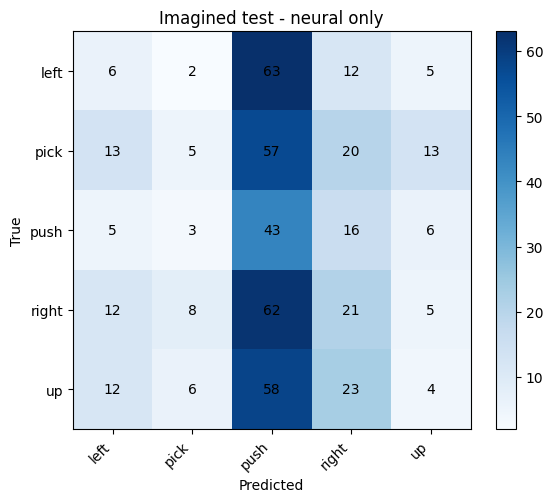

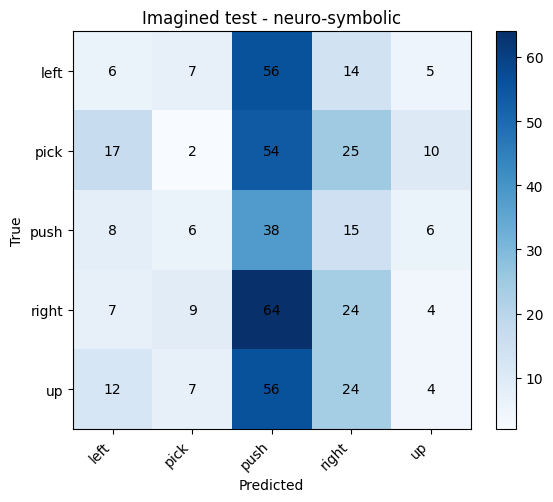

In [40]:
# Confusion matrices

def show_cm(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

if X_all is not None and split_ready:
    # Neural only
    show_cm(
        imag_test_metrics["y_true"],
        imag_test_metrics["neural_pred"],
        label_encoder.classes_,
        "Imagined test - neural only"
    )

    # Neuro-symbolic (final output)
    show_cm(
        imag_test_metrics["y_true"],
        imag_test_metrics["y_pred"],
        label_encoder.classes_,
        "Imagined test - neuro-symbolic"
    )
else:
    print("Confusion matrices skipped because imagined evaluation is not ready.")

In [41]:
# Test the end-to-end neuro-symbolic AI on one subject (participant_12)

SUBJECT_TO_TEST = "participant_12"
N_EXAMPLES_TO_SHOW = CONFIG.get("explanation_examples_to_show", 10)


def predict_with_context_numpy(model, X, C, batch_size=64):
    model.eval()
    final_probs, neural_probs = [], []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb = torch.as_tensor(X[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            cb = torch.as_tensor(C[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            outputs = run_model_forward(model, xb, cb)
            final_probs.append(outputs["adjusted_probs"].detach().cpu().numpy())
            neural_probs.append(outputs["neural_probs"].detach().cpu().numpy())
    if not final_probs:
        return np.empty((0, len(label_encoder.classes_))), np.empty((0, len(label_encoder.classes_)))
    return np.vstack(final_probs), np.vstack(neural_probs)


def build_explanation_table(meta_part, neural_probs, context_part):
    rows = []
    traces = []
    for i in range(len(neural_probs)):
        current_model = transfer_model if meta_part.iloc[i]["paradigm"] == "imagined" else overt_model
        trace = explain_single_prediction(
            current_model,
            probs=neural_probs[i],
            context_vec=context_part[i],
            class_names=label_encoder.classes_,
            context_columns=context_columns,
        )
        traces.append(trace)
        rows.append({
            "subject": meta_part.iloc[i]["subject"],
            "paradigm": meta_part.iloc[i]["paradigm"],
            "true_command": meta_part.iloc[i]["command"],
            "neural_decision": trace.neural_decision,
            "final_decision": trace.final_decision,
            "neural_confidence": round(trace.neural_confidence, 4),
            "final_confidence": round(trace.final_confidence, 4),
            "decision_changed": trace.decision_changed,
            "human_readable_explanation": trace.explanation_text,
            "fired_rules": " | ".join(trace.fired_rules) if trace.fired_rules else "No symbolic rule fired strongly enough to verbalize.",
            "neural_probs": trace.neural_probs,
            "final_probs": trace.final_probs,
        })
    return pd.DataFrame(rows), traces


def summarize_subject_rules(traces, title):
    print(f"\n=== {title} : HUMAN-READABLE RULE SUMMARY ===")
    if not traces:
        print("No samples available.")
        return

    from collections import Counter

    rule_counter = Counter()
    changed = 0
    final_counter = Counter()

    for trace in traces:
        final_counter[trace.final_decision] += 1
        if trace.decision_changed:
            changed += 1
        for rule in trace.fired_rules:
            rule_counter[rule] += 1

    print(f"Total samples: {len(traces)}")
    print(f"Samples where symbolic reasoning changed the neural decision: {changed}")
    print("Most common final decisions:", dict(final_counter.most_common()))
    print("\nMost frequent human-readable symbolic rules:")
    if rule_counter:
        for i, (rule, count) in enumerate(rule_counter.most_common(8), 1):
            print(f"{i}. {rule} [count={count}]")
    else:
        print("No rule fired strongly enough to summarize.")


def print_example_explanations(df, traces, title, n_examples=5):
    print(f"\n=== {title} : SAMPLE-BY-SAMPLE HUMAN-READABLE EXPLANATIONS ===")
    if len(df) == 0:
        print("No samples available.")
        return
    n_show = min(n_examples, len(df))
    for i in range(n_show):
        row = df.iloc[i]
        trace = traces[i]
        print(f"\nSample {i + 1}")
        print(f"True command      : {str(row['true_command']).upper()}")
        print(f"Neural decision   : {str(row['neural_decision']).upper()} ({row['neural_confidence']:.4f})")
        print(f"Final decision    : {str(row['final_decision']).upper()} ({row['final_confidence']:.4f})")
        print("Why this output?")
        print(trace.explanation_text)
        if trace.fired_rules:
            print("Human-readable rules:")
            for j, rule in enumerate(trace.fired_rules, 1):
                print(f"  {j}. {rule}")


subject_path = next((p for p in fif_files if infer_subject_id(p) == SUBJECT_TO_TEST), None)
if subject_path is None:
    raise ValueError(f"Could not find {SUBJECT_TO_TEST} in fif_files.")

print("Testing subject:", SUBJECT_TO_TEST)
print("Path:", subject_path)

raw_subj = load_raw(subject_path)
X_subj, y_subj_names, paradigm_subj, meta_subj, epochs_subj, debug_subj = extract_epochs_from_raw(
    raw_subj, SUBJECT_TO_TEST, subject_path, return_debug=True
)

if X_subj is None or len(X_subj) == 0:
    raise ValueError(f"No usable epochs found for {SUBJECT_TO_TEST}. Debug: {debug_subj}")

print("Subject epoch shape:", X_subj.shape)
display(meta_subj.groupby(["paradigm", "command"]).size().rename("n_epochs").reset_index())

if "common_chs" in globals():
    subj_ch_names = list(epochs_subj.ch_names)
    missing = [ch for ch in common_chs if ch not in subj_ch_names]
    if missing:
        raise ValueError(f"Subject is missing some common training channels: {missing[:10]}")
    ch_idx = [subj_ch_names.index(ch) for ch in common_chs]
    X_subj = X_subj[:, ch_idx, :]
    print("Aligned subject shape to common channels:", X_subj.shape)

if "mu_o" not in globals() or "sigma_o" not in globals():
    raise ValueError("mu_o / sigma_o not found. Run the split/normalization cell first.")

X_subj_norm = (X_subj - mu_o) / sigma_o
C_subj_df, context_columns = build_context_features(meta_subj, label_encoder.classes_)
C_subj = C_subj_df.to_numpy(dtype=np.float32)

overt_mask_subj = (np.asarray(paradigm_subj) == "overt")
imag_mask_subj = (np.asarray(paradigm_subj) == "imagined")

X_subj_overt, C_subj_overt = X_subj_norm[overt_mask_subj], C_subj[overt_mask_subj]
X_subj_imag, C_subj_imag = X_subj_norm[imag_mask_subj], C_subj[imag_mask_subj]
meta_subj_overt = meta_subj.loc[overt_mask_subj].reset_index(drop=True)
meta_subj_imag = meta_subj.loc[imag_mask_subj].reset_index(drop=True)
y_subj_overt = label_encoder.transform(meta_subj_overt["command"]) if len(meta_subj_overt) else np.array([], dtype=int)
y_subj_imag = label_encoder.transform(meta_subj_imag["command"]) if len(meta_subj_imag) else np.array([], dtype=int)

print("Overt subject epochs:", len(y_subj_overt))
print("Imagined subject epochs:", len(y_subj_imag))

if "overt_model" not in globals():
    raise ValueError("overt_model not found. Run overt training first.")
if "transfer_model" not in globals():
    raise ValueError("transfer_model not found. Run imagined transfer first.")

overt_final_probs, overt_neural_probs = predict_with_context_numpy(overt_model, X_subj_overt, C_subj_overt, batch_size=64) if len(X_subj_overt) else (np.empty((0, len(label_encoder.classes_))), np.empty((0, len(label_encoder.classes_))))
imag_final_probs, imag_neural_probs = predict_with_context_numpy(transfer_model, X_subj_imag, C_subj_imag, batch_size=64) if len(X_subj_imag) else (np.empty((0, len(label_encoder.classes_))), np.empty((0, len(label_encoder.classes_))))

overt_final_pred = np.argmax(overt_final_probs, axis=1) if len(overt_final_probs) else np.array([], dtype=int)
overt_neural_pred = np.argmax(overt_neural_probs, axis=1) if len(overt_neural_probs) else np.array([], dtype=int)
imag_final_pred = np.argmax(imag_final_probs, axis=1) if len(imag_final_probs) else np.array([], dtype=int)
imag_neural_pred = np.argmax(imag_neural_probs, axis=1) if len(imag_neural_probs) else np.array([], dtype=int)

overt_explain_df, overt_traces = build_explanation_table(meta_subj_overt, overt_neural_probs, C_subj_overt) if len(overt_neural_probs) else (pd.DataFrame(), [])
imag_explain_df, imag_traces = build_explanation_table(meta_subj_imag, imag_neural_probs, C_subj_imag) if len(imag_neural_probs) else (pd.DataFrame(), [])


def print_metrics_block(title, y_true, y_neural, y_final):
    print(f"\n=== {title} ===")
    if len(y_true) == 0:
        print("No samples.")
        return
    print(f"Neural      acc={accuracy_score(y_true, y_neural):.4f}  bacc={balanced_accuracy_score(y_true, y_neural):.4f}")
    print(f"NeuroSym    acc={accuracy_score(y_true, y_final):.4f}  bacc={balanced_accuracy_score(y_true, y_final):.4f}")
    print("\nNeuro-symbolic report:")
    print(classification_report(y_true, y_final, target_names=label_encoder.classes_, digits=4, zero_division=0))


print_metrics_block("PARTICIPANT 12 - OVERT", y_subj_overt, overt_neural_pred, overt_final_pred)
print_metrics_block("PARTICIPANT 12 - IMAGINED", y_subj_imag, imag_neural_pred, imag_final_pred)

summarize_subject_rules(overt_traces, "PARTICIPANT 12 - OVERT")
summarize_subject_rules(imag_traces, "PARTICIPANT 12 - IMAGINED")

print("\n=== Example OVERT predictions with explainability ===")
display(overt_explain_df.head(N_EXAMPLES_TO_SHOW))

print("\n=== Example IMAGINED predictions with explainability ===")
display(imag_explain_df.head(N_EXAMPLES_TO_SHOW))

print_example_explanations(overt_explain_df, overt_traces, "PARTICIPANT 12 - OVERT", n_examples=N_EXAMPLES_TO_SHOW)
print_example_explanations(imag_explain_df, imag_traces, "PARTICIPANT 12 - IMAGINED", n_examples=N_EXAMPLES_TO_SHOW)

Testing subject: participant_12
Path: /home/naveed/Desktop/EEG data recorded during spoken and imagined speech interaction with a simulated robot/participant_12.fif
Reading 0 ... 2494959  =      0.000 ...  4989.918 secs...
Subject epoch shape: (500, 63, 257)


,paradigm,command,n_epochs
0,imagined,left,50
1,imagined,pick,50
2,imagined,push,50
3,imagined,right,50
4,imagined,up,50
5,overt,left,50
6,overt,pick,50
7,overt,push,50
8,overt,right,50
9,overt,up,50


Aligned subject shape to common channels: (500, 52, 257)
Overt subject epochs: 250
Imagined subject epochs: 250

=== PARTICIPANT 12 - OVERT ===
Neural      acc=0.3000  bacc=0.3000
NeuroSym    acc=0.2760  bacc=0.2760

Neuro-symbolic report:
              precision    recall  f1-score   support

        left     0.3333    0.2200    0.2651        50
        pick     0.5500    0.2200    0.3143        50
        push     0.2389    0.5400    0.3313        50
       right     0.2069    0.2400    0.2222        50
          up     0.3077    0.1600    0.2105        50

    accuracy                         0.2760       250
   macro avg     0.3274    0.2760    0.2687       250
weighted avg     0.3274    0.2760    0.2687       250


=== PARTICIPANT 12 - IMAGINED ===
Neural      acc=0.2320  bacc=0.2320
NeuroSym    acc=0.2160  bacc=0.2160

Neuro-symbolic report:
              precision    recall  f1-score   support

        left     0.4667    0.1400    0.2154        50
        pick     0.2667    0.08

,subject,paradigm,true_command,neural_decision,final_decision,neural_confidence,final_confidence,decision_changed,human_readable_explanation,fired_rules,neural_probs,final_probs
0,participant_12,overt,left,push,push,0.2308,0.2384,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.21250339, 0.19838691, 0.23078677, 0.1756583...","[0.21219799, 0.19713181, 0.23835336, 0.1758221..."
1,participant_12,overt,push,left,up,0.3107,0.2724,True,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.31067026, 0.12971681, 0.18112272, 0.1390827...","[0.19600244, 0.151029, 0.21762897, 0.1628981, ..."
2,participant_12,overt,push,up,right,0.2794,0.2992,True,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.19299924, 0.07798375, 0.17784616, 0.2717963...","[0.212043, 0.0853053, 0.105340175, 0.29924598,..."
3,participant_12,overt,pick,left,left,0.3219,0.3587,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.32192904, 0.13667844, 0.21244563, 0.1027904...","[0.35873568, 0.15171762, 0.12923133, 0.1147575..."
4,participant_12,overt,pick,left,push,0.2289,0.2544,True,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.2288992, 0.16212815, 0.2270024, 0.20251605,...","[0.24802326, 0.08946079, 0.2544321, 0.21995856..."
5,participant_12,overt,right,push,push,0.2161,0.2404,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.21443269, 0.14242959, 0.21612428, 0.2137827...","[0.23036668, 0.07758132, 0.24038725, 0.2302297..."
6,participant_12,overt,push,left,left,0.2775,0.3031,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.27753153, 0.13434696, 0.22378978, 0.1840676...","[0.3030829, 0.1460729, 0.25188124, 0.10782164,..."
7,participant_12,overt,up,left,left,0.2507,0.2837,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.25069425, 0.12598386, 0.23337293, 0.2002664...","[0.2836569, 0.14188153, 0.1393809, 0.22711301,..."
8,participant_12,overt,pick,push,push,0.3290,0.3591,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.21699181, 0.15988205, 0.3290129, 0.15170261...","[0.23074223, 0.16937187, 0.35906637, 0.1616108..."
9,participant_12,overt,up,push,push,0.2638,0.2959,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.16817123, 0.17349708, 0.26382795, 0.2250373...","[0.1827886, 0.09755725, 0.29586104, 0.24513505..."



=== Example IMAGINED predictions with explainability ===


,subject,paradigm,true_command,neural_decision,final_decision,neural_confidence,final_confidence,decision_changed,human_readable_explanation,fired_rules,neural_probs,final_probs
0,participant_12,imagined,push,up,up,0.2316,0.2272,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.19184278, 0.16422065, 0.20868562, 0.2036958...","[0.19122432, 0.16615535, 0.21318097, 0.2021994..."
1,participant_12,imagined,push,push,right,0.2506,0.2334,True,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.2031021, 0.17105667, 0.25063142, 0.20644395...","[0.23062652, 0.19716169, 0.14986715, 0.2334468..."
2,participant_12,imagined,right,up,up,0.2282,0.2480,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.19962358, 0.16614006, 0.19396195, 0.2121242...","[0.2204872, 0.18626663, 0.11187182, 0.23332627..."
3,participant_12,imagined,push,push,push,0.2687,0.3029,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.17209749, 0.1770093, 0.26868927, 0.21536244...","[0.18977222, 0.19812535, 0.30288818, 0.1276557..."
4,participant_12,imagined,pick,pick,pick,0.2176,0.2443,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.19424075, 0.2176221, 0.19828095, 0.19442613...","[0.21484435, 0.24432948, 0.11402133, 0.2141633..."
5,participant_12,imagined,pick,push,push,0.2851,0.3166,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.18075308, 0.18260674, 0.28508258, 0.2005994...","[0.19661856, 0.10721331, 0.31664953, 0.2172908..."
6,participant_12,imagined,up,push,push,0.2668,0.2956,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.21074913, 0.17290628, 0.26678038, 0.1801930...","[0.22843204, 0.10027469, 0.2956496, 0.19449681..."
7,participant_12,imagined,pick,push,push,0.2257,0.2517,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.19446392, 0.1841655, 0.22566447, 0.21583606...","[0.21152215, 0.20333594, 0.25165248, 0.2337995..."
8,participant_12,imagined,pick,push,push,0.2653,0.2939,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.17806685, 0.17196424, 0.2652562, 0.21108264...","[0.19297354, 0.0996382, 0.29393956, 0.22779827..."
9,participant_12,imagined,push,push,push,0.2195,0.2467,False,LEFT received a feasibility boost from the sym...,LEFT received a feasibility boost from the sym...,"[0.2019732, 0.18767412, 0.21948282, 0.20577219...","[0.22134997, 0.1077868, 0.24670391, 0.22458375..."



=== PARTICIPANT 12 - OVERT : SAMPLE-BY-SAMPLE HUMAN-READABLE EXPLANATIONS ===

Sample 1
True command      : LEFT
Neural decision   : PUSH (0.2308)
Final decision    : PUSH (0.2384)
Why this output?
LEFT received a feasibility boost from the symbolic layer. PICK received a feasibility boost from the symbolic layer. PUSH received a feasibility boost from the symbolic layer. RIGHT received a feasibility boost from the symbolic layer. UP received a feasibility boost from the symbolic layer. The symbolic layer became more active because the neural confidence was low. The final output remained PUSH because it stayed the most supported valid command.
Human-readable rules:
  1. LEFT received a feasibility boost from the symbolic layer.
  2. PICK received a feasibility boost from the symbolic layer.
  3. PUSH received a feasibility boost from the symbolic layer.
  4. RIGHT received a feasibility boost from the symbolic layer.
  5. UP received a feasibility boost from the symbolic layer.

Sampl